# 010. KV キャッシュと推論の計算量(KV Cache and Inference Compute)

## 1. 概要 / Overview

自己回帰生成(autoregressive generation)では、各生成ステップで同じ Key / Value を
繰り返し計算する冗長性がある。この冗長性を取り除く **KV キャッシュ(KV Cache)** の
仕組みと、それが生成の時間計算量・メモリ量に与える影響を扱う。特に、文脈全体を
一度に処理する **prefill** と 1 トークンずつ処理する **decode** という 2 つの
フェーズの非対称性(計算律速とメモリ帯域律速)に注目し、Key / Value ヘッド数を
削減してキャッシュを縮小する MQA(Multi-Query Attention)・GQA(Grouped-Query
Attention)の効果を実験で検証する。

## 2. 参考論文 / References

1. Shazeer, N. "Fast Transformer Decoding: One Write-Head is All You Need."
   arXiv:1911.02150, 2019. https://arxiv.org/abs/1911.02150
2. Ainslie, J., Lee-Thorp, J., de Jong, M., Zemlyanskiy, Y., Lebrón, F., Sanghai, S.
   "GQA: Training Generalized Multi-Query Transformer Models from Multi-Head
   Checkpoints." EMNLP 2023. https://arxiv.org/abs/2305.13245
3. Pope, R., Douglas, S., Chowdhery, A., Devlin, J., Bradbury, J., Levskaya, A.,
   Heek, J., Xiao, K., Agrawal, S., Dean, J. "Efficiently Scaling Transformer
   Inference." MLSys 2023. https://arxiv.org/abs/2211.05102
4. Kwon, W., Li, Z., Zhuang, S., Sheng, Y., Zheng, L., Yu, C. H., Gonzalez, J. E.,
   Zhang, H., Stoica, I. "Efficient Memory Management for Large Language Model
   Serving with PagedAttention." SOSP 2023. https://arxiv.org/abs/2309.06180
   (メモリ断片化への対処。本ノートブックでは理論の位置づけとして言及するのみで、
   実装・実験の対象にはしない)

## 3. 理論 / Theory

### 3.1 自己回帰生成における再計算の冗長性

記号(このセクション共通):

- $T$: 生成するトークン数
- $L$: 層数(num_layers)
- $h$: 多頭注意機構(Multi-Head Attention)のヘッド数
- $d_{\mathrm{model}}$: モデルの隠れ次元
- $d_k$: ヘッドあたりの次元($= d_{\mathrm{model}} / h$)

003([位置エンコーディング(RoPE)](../01_foundations/003_positional_encoding_rope.ipynb))
までの`GPTLanguageModel.generate()`(006〜008)は、生成ステップ $t$ ごとに、
その時点までの系列全体(長さ $t$)を`forward()`に丸ごと渡し直す。すなわち、
ステップ $t$ の計算には以下が含まれる。

- **Query / Key / Value の線形射影**: 系列長 $t$ の入力を $d_{\mathrm{model}}
  \times d_{\mathrm{model}}$ の行列で変換するため、1 層あたり $O(t \, d_{\mathrm{model}}^2)$。
- **Attention 本体(スコア計算 + 加重和)**: $t \times t$ のスコア行列を計算するため、
  1 層あたり $O(t^2 d_{\mathrm{model}})$(ヘッド数 $h$ に分割しても
  $h \times (t^2 d_k) = t^2 (h d_k) = t^2 d_{\mathrm{model}}$ で変わらない)。

$T$ トークンを生成するには、この計算を $t = 1, \dots, T$ について毎回すべて
やり直す。$\sum_{t=1}^{T} t = O(T^2)$、$\sum_{t=1}^{T} t^2 = O(T^3)$ であるから、
1 層あたりの総計算量は

$$
\underbrace{O(T^2 d_{\mathrm{model}}^2)}_{\text{linear projections}}
+ \underbrace{O(T^3 d_{\mathrm{model}})}_{\text{attention}}
$$

(第 1 項が線形射影の総和、第 2 項が Attention 本体の総和である)

$L$ 層分では、これに $L$ を掛けた $O(L T^2 d_{\mathrm{model}}^2 + L T^3
d_{\mathrm{model}})$ になる(層数 $L$ はアーキテクチャを固定すれば定数とみなせる
ため、以降では単に $O(T^3 d_{\mathrm{model}} + T^2 d_{\mathrm{model}}^2)$ と書く)。

**KV キャッシュ** は、ステップ $t$ で計算した Key / Value を保持しておき、
ステップ $t+1$ では新規トークン 1 個分の Key / Value だけを計算して追記する
仕組みである。これにより、ステップ $t$ の計算は次で済む。

- **新規トークン分の線形射影**: 系列長 1 の入力を変換するだけなので
  $O(d_{\mathrm{model}}^2)$(定数)。
- **Attention 本体**: 新規の Query 1 個と、キャッシュ済みの長さ $t$ の
  Key / Value との内積なので $O(t \, d_{\mathrm{model}})$。

$T$ ステップの総和は $\sum_{t=1}^{T} 1 = O(T)$、$\sum_{t=1}^{T} t = O(T^2)$ から、

$$
O(T \, d_{\mathrm{model}}^2) + O(T^2 d_{\mathrm{model}})
$$

キャッシュなしの $O(T^3 d_{\mathrm{model}} + T^2 d_{\mathrm{model}}^2)$ から、
キャッシュありの $O(T^2 d_{\mathrm{model}} + T d_{\mathrm{model}}^2)$ へ、
$T$ に対する次数がそれぞれ 1 つずつ下がる。これが実験 A で検証する内容である。

下図は、1 生成ステップにおけるデータフローの違いを示す(キャッシュなしは
系列全体を毎回計算し直すのに対し、キャッシュありは新規トークン分のみを計算し
過去の結果に追記する)。

```mermaid
flowchart LR
    subgraph NOCACHE["キャッシュなし(No Cache)"]
        direction TB
        A1["トークン列(長さ t、全体)"] --> B1["全 t 個を Q, K, V に射影"]
        B1 --> C1["Attention: t × t 個のスコアを計算"]
        C1 --> D1["次トークンの logits"]
    end
    subgraph CACHE["KV キャッシュあり(With KV Cache)"]
        direction TB
        A2["新規トークン 1 個"] --> B2["新規分のみ Q, K, V に射影"]
        F2["キャッシュ済み K, V(過去 t-1 個分)"] --> E2["KeyValueCache に追記"]
        B2 --> E2
        E2 --> C2["Attention: 新規 Query 1 個 × 全 t 個の Key/Value"]
        C2 --> D2["次トークンの logits"]
    end
```

### 3.2 キャッシュのメモリ量の閉形式

記号(前節に加えて):

- $B$: バッチサイズ
- $g$: Key / Value ヘッド数(num_key_value_heads。多頭注意機構では $g = h$)
- $\text{bytes\_per\_element}$: 要素あたりバイト数(fp32 なら 4、fp16 / bf16 なら 2)

層 $l$ の KV キャッシュは、Key・Value それぞれ形状 $(B, g, T, d_k)$ のテンソルであり、
要素数は $B \, g \, T \, d_k$。Key と Value の 2 つを保持するので、1 層あたりの
バイト数は $2 \, B \, g \, T \, d_k \times \text{bytes\_per\_element}$。これを
$L$ 層分合計すると、

$$
\text{memory}
= 2 \cdot B \cdot L \cdot T \cdot (g \cdot d_k) \cdot \text{bytes\_per\_element}
$$

多頭注意機構では $g = h$ であり $g \cdot d_k = d_{\mathrm{model}}$ なので、この式は
$2 \, B \, L \, T \, d_{\mathrm{model}} \cdot \text{bytes\_per\_element}$ になる
(`compute_key_value_cache_memory_bytes`、`src/utils/statistics.py`)。系列長
$T$ に **線形** で増えることが、prefill と異なる decode 特有の性質である
(prefill 自体はキャッシュを増やすだけで、モデル本体の計算量が $T$ に対して
線形に留まるわけではない。3.1 節参照)。

In [1]:
# 環境セットアップ(Google Colab)
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    get_ipython().system("git clone https://github.com/kojikojiprg/ai-theories.git")
    get_ipython().run_line_magic("cd", "ai-theories")
    get_ipython().system("pip install uv -q")
    get_ipython().system("uv pip install --system -r requirements.txt")
# ローカル(Jupyter)実行時は、リポジトリルートで起動していればそのまま動く。

import functools
import hashlib
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

from src.data.text import (
    encode_corpus,
    load_wikipedia_corpus,
    make_evaluation_windows,
    split_train_val_text,
)
from src.data.tokenizer import load_bpe_id_tokenizer_from_hub
from src.generation.cache import KeyValueCache
from src.layers.attention import MultiHeadAttention, create_causal_mask
from src.layers.feedforward import SwiGLUFeedForwardNetwork
from src.layers.normalization import RMSNorm
from src.layers.positional_encoding import RotaryPositionEmbedding
from src.models.gpt import GPTLanguageModel, convert_attention_to_grouped_query
from src.training.trainer import evaluate_bits_per_byte, train_language_model
from src.utils.statistics import (
    compute_arithmetic_intensity,
    compute_key_value_cache_memory_bytes,
    count_non_embedding_parameters,
    fit_power_law_exponent,
)
from src.utils.visualization import plot_log_log_fit

ROOT = Path(".")
RAWDATA_DIR = ROOT / ".rawdata"
RAWDATA_DIR.mkdir(parents=True, exist_ok=True)

SMOKE_TEST = True  # Claude Code はこの True 側のみ実行する(Colab T4 では False に切り替える)

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)
# 時間計測(実験 A・B・C・D)専用のデバイス。実験 B・C は decode がメモリ帯域律速で
# あること(GPU 固有の性質)そのものを検証するため、CUDA が使える環境では必ず CUDA を
# 使う(DEVICE をそのまま使う)。この Mac の MPS バックエンドは、本ノートブックのような
# 小さいテンソルに対するカーネル起動オーバーヘッドが大きく、変動係数(CV)が前提条件
# P0(0.1 以下)を安定して満たさない(ローカルで実測済み)ため、MPS のときのみ CPU に
# 落とす(CPU は決定的で高速なため P0 を安定して満たせる。Claude Code によるローカル
# 実行(第 1 段階)はこの経路を通る)。Google Colab T4 GPU での本番実行(第 2 段階)は
# CUDA が使えるため、DEVICE(= cuda)がそのまま使われる。
TIMING_DEVICE = DEVICE if DEVICE.type == "cuda" else torch.device("cpu")


def sync(device: torch.device) -> None:
    '''時間計測の前後で呼ぶデバイス同期(前提条件 P0)。'''
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


def is_oom_error(exc: BaseException) -> bool:
    '''out-of-memory 例外の判定(``torch.OutOfMemoryError``は PyTorch 2.5 以降の
    属性であり、Colab のバージョンによっては存在しない場合があるため、例外の
    クラス名・メッセージ文字列でも判定できるようにする)。
    '''
    name = type(exc).__name__
    return "OutOfMemory" in name or "out of memory" in str(exc).lower()


def warn_if_unreliable_fit(fit, name: str) -> None:
    '''べき乗則あてはめの標準誤差が推定値と同程度以上の場合に警告を出力する。
    外挿が信用できない状態を、合計値へ静かに混ぜないための安全弁。
    '''
    if fit.exponent_stderr >= abs(fit.exponent):
        print(
            f"[警告] {name} のべき指数の標準誤差({fit.exponent_stderr:.3f})が推定値"
            f"({fit.exponent:.3f})と同程度以上であり、この外挿は信用できない。"
            "水準・反復回数を増やして再計測すること。"
        )


print(f"torch: {torch.__version__} / DEVICE: {DEVICE} / TIMING_DEVICE: {TIMING_DEVICE}")
print(f"SMOKE_TEST: {SMOKE_TEST}")
if TIMING_DEVICE.type != "cuda":
    print(
        "[注記] TIMING_DEVICE が CUDA ではない。実験 B・C の "
        "「decode はメモリ帯域律速」という仮説自体が GPU 固有の性質であるため、"
        "CUDA 環境(Google Colab T4 GPU)で再実行するまでは結果を確定させないこと。"
    )

torch: 2.13.0 / DEVICE: mps / TIMING_DEVICE: cpu
SMOKE_TEST: True
[注記] TIMING_DEVICE が CUDA ではない。実験 B・C の 「decode はメモリ帯域律速」という仮説自体が GPU 固有の性質であるため、CUDA 環境(Google Colab T4 GPU)で再実行するまでは結果を確定させないこと。


### 3.3 prefill と decode の非対称性

本トピックの中心的な洞察は、生成の 2 つのフェーズ **prefill**(起点となる文脈
全体を 1 回の順伝播でまとめて処理する)と **decode**(KV キャッシュを使い、
新規トークン 1 個ずつを逐次処理する)が、計算資源の使われ方の点で対称ではない
ことである。

**演算強度(arithmetic intensity)** は、ある演算が読み書きするメモリの
バイト数に対する浮動小数点演算回数(FLOPs)の比

$$
\text{AI} = \frac{\text{FLOPs}}{\text{bytes moved}}
$$

で定義される(`compute_arithmetic_intensity`)。roofline モデル(Williams et al.,
"Roofline: An Insightful Visual Performance Model for Multicore Architectures",
CACM 2009)では、ハードウェアごとに定まる **ridge point**

$$
\text{AI}_{\text{ridge}} = P_{\text{peak}} / BW
$$

を境に演算の律速要因が切り替わる($P_{\text{peak}}$ はハードウェアのピーク演算性能
(FLOPS)、$BW$ はメモリ帯域幅(bytes/s))。ridge point より演算強度が低い演算は、
演算器がメモリからのデータ供給を待つ **メモリ帯域律速(memory-bound)** になり、
高い演算はメモリ帯域が余っていても演算器が追いつかない **計算律速(compute-bound)**
になる。

線形層(重み $(d_{\text{in}}, d_{\text{out}})$、入力 $N$ 行、要素あたり
$\text{bytes\_per\_element}$ バイト)を例にとる。

- FLOPs: $2 N d_{\text{in}} d_{\text{out}}$(積和 1 回を 2 演算と数える標準的な近似)
- bytes moved: 重みの読み出し $d_{\text{in}} d_{\text{out}} \cdot
  \text{bytes\_per\_element}$ + 入出力活性化の読み書き
  $N (d_{\text{in}} + d_{\text{out}}) \cdot \text{bytes\_per\_element}$

**prefill**($N = B \cdot S$、$S$ は文脈全体の系列長)では、$N$ が大きいほど
FLOPs は $N$ に比例して増える一方、重みの読み出しバイト数は $N$ によらず一定
(1 回の呼び出しにつき 1 回だけ読む)ため、$N$ が大きいほど演算強度は大きくなる
(重みの読み出しコストが多くの演算で「償却」される)。

**decode**($N = B$、系列長 1 の新規トークンのみ)では、$B$ が小さい典型的な
生成では $N$ が小さく、重みバイト数が総バイト数の大部分を占め続ける。1 ステップ
ごとに同じ重みを読み直すコストを、そのステップの少ない演算量では償却できない
ため、演算強度は低いまま(概ね $O(B)$、$B=1$ では $O(1)$)に留まる。

このため decode はメモリ帯域律速になりやすく、KV キャッシュのメモリ量(3.2 節)を
減らすこと(MQA・GQA)が、decode の速度に直接効いてくる。実験 B は、この非対称性を
バッチサイズ依存性の差として検証する。

In [2]:
# 数値例: 線形層 1 個(d_in = d_out = D_MODEL)の演算強度を、decode(N=1)と
# prefill(N=系列長)で比較する。d_model・要素あたりバイト数は本ノートブック共通の
# 本番モデル構成(6 節)を先取りして使う。
_EXAMPLE_D_MODEL = 256
_EXAMPLE_BYTES_PER_ELEMENT = 4  # fp32
_weight_bytes = _EXAMPLE_D_MODEL * _EXAMPLE_D_MODEL * _EXAMPLE_BYTES_PER_ELEMENT


def _linear_layer_ai(n: int) -> float:
    flops = 2 * n * _EXAMPLE_D_MODEL * _EXAMPLE_D_MODEL
    activation_bytes = n * 2 * _EXAMPLE_D_MODEL * _EXAMPLE_BYTES_PER_ELEMENT
    bytes_moved = _weight_bytes + activation_bytes
    return compute_arithmetic_intensity(flops, bytes_moved)


ai_decode = _linear_layer_ai(1)  # decode: B=1, 系列長 1
ai_prefill_256 = _linear_layer_ai(256)  # prefill: 系列長 256
print(f"演算強度(decode, N=1):    {ai_decode:.3f} FLOPs/byte")
print(f"演算強度(prefill, N=256): {ai_prefill_256:.3f} FLOPs/byte")
print(f"比(prefill / decode): {ai_prefill_256 / ai_decode:.1f} 倍")

# 診断量: T4 GPU の公称値(FP32 ピーク ~8.1 TFLOPS、メモリ帯域 ~320 GB/s)との対比。
# この絶対値の一致は判定基準にしない(実測の達成帯域は公称値の 7 割前後であり、
# 真偽を判定できる形にはならない。CLAUDE.md の実験 B 宣言セル参照)。
_T4_PEAK_FLOPS = 8.1e12
_T4_BANDWIDTH_BYTES_PER_SEC = 320e9
_t4_ridge_point = _T4_PEAK_FLOPS / _T4_BANDWIDTH_BYTES_PER_SEC
print(f"\n[診断量] T4 GPU の ridge point(公称値): {_t4_ridge_point:.2f} FLOPs/byte")
print(f"[診断量] decode の演算強度は ridge point の {ai_decode / _t4_ridge_point:.1%}")
print(f"[診断量] prefill(N=256) の演算強度は ridge point の {ai_prefill_256 / _t4_ridge_point:.1%}")

演算強度(decode, N=1):    0.496 FLOPs/byte
演算強度(prefill, N=256): 42.667 FLOPs/byte
比(prefill / decode): 86.0 倍

[診断量] T4 GPU の ridge point(公称値): 25.31 FLOPs/byte
[診断量] decode の演算強度は ridge point の 2.0%
[診断量] prefill(N=256) の演算強度は ridge point の 168.6%


### 3.4 MQA(Multi-Query Attention)と GQA(Grouped-Query Attention)

3.2 節の閉形式が示す通り、KV キャッシュのメモリ量は Key / Value ヘッド数 $g$ に
比例する。Shazeer (2019) の **MQA** は $g = 1$(全ての Query ヘッドが単一の
Key / Value ヘッドを共有する)、Ainslie et al. (2023) の **GQA** はその中間
($1 < g < h$、Query ヘッドを $h/g$ 個ずつのグループに分け、グループ内で
Key / Value ヘッドを共有する)を提案した。いずれも、キャッシュのメモリ量を
$g/h$ 倍に縮小する(Query 側の射影 $W^Q$・出力射影 $W^O$ は変更しない)。

```mermaid
flowchart TB
    subgraph MHA["多頭注意機構(h=8, g=8)"]
        direction LR
        mq1["Query head 1"] --- mk1["KV head 1"]
        mq2["Query head 2"] --- mk2["KV head 2"]
        mqd["..."] --- mkd["..."]
        mq8["Query head 8"] --- mk8["KV head 8"]
    end
    subgraph GQA["GQA(h=8, g=4)"]
        direction LR
        gq12["Query head 1, 2"] --> gk1["KV head 1"]
        gq34["Query head 3, 4"] --> gk2["KV head 2"]
        gq56["Query head 5, 6"] --> gk3["KV head 3"]
        gq78["Query head 7, 8"] --> gk4["KV head 4"]
    end
    subgraph MQA["MQA(h=8, g=1)"]
        direction LR
        mqall["Query head 1..8(全て)"] --> mk["KV head 1"]
    end
```

**uptraining**(Ainslie et al., 2023): 既存の多頭注意機構チェックポイントから
GQA / MQA へ変換する際、Key / Value の射影行列をランダムに初期化すると、
学習済みの Query・出力射影との整合が崩れ、追加学習の初期の損失が大きく跳ね上がる。
Ainslie らは、グループ内の元の Key / Value ヘッドの重みを **平均プール
(mean pooling)** して初期化する方法を提案し、ランダム初期化より少ない追加学習
ステップ数で高い性能に到達することを示した(`convert_attention_to_grouped_query`
の`init="mean_pool"`、実験 D で検証する)。

### 3.5 RoPE とキャッシュの相互作用

003([位置エンコーディング(RoPE)](../01_foundations/003_positional_encoding_rope.ipynb))
で導入した RoPE(Rotary Position Embedding、Su et al., Neurocomputing 2024)は、
Query・Key の各トークンをその **絶対位置** $m$ だけ回転させる
(`RotaryPositionEmbedding.apply`)。この回転は他のトークンの値に一切依存しない
(トークン $m$ の回転は $m$ だけで決まる)ため、系列全体をまとめて回転させても、
1 トークンずつ回転させて後から連結しても、結果は完全に同じになる。

これが、KV キャッシュと RoPE の相互作用の核心である。decode の各ステップで
新規トークンに RoPE を適用する際、**その系列内での相対位置(常に 0)ではなく、
キャッシュ長だけずれた絶対位置** を使う必要がある。003 の時点で
`MultiHeadAttention.forward`・`RotaryPositionEmbedding.apply`・`DecoderBlock.forward`
はいずれも`positions`引数(Query の絶対位置インデックス)を既に持っており、
docstring にも「KV キャッシュを用いた逐次推論(トピック 010)では、生成の各
ステップで Query の絶対位置がキャッシュ長だけずれるため、これを外部から指定
できるようにしている」と明記されていた。010 の実装(`GPTLanguageModel.generate`
の`use_cache=True`パス)は、この 003 の設計をそのまま使う。具体的には、prefill
ステップでは`positions = arange(S_0)`、decode の各ステップでは
`positions = [kv_cache.length]`(その時点のキャッシュ長)を渡す。

## 4. 実装方針 / Implementation Policy

**ノートブック内に直接書くもの**(`src/`に置かない): 3.1 節の導入として、
Attention 層自身が過去の Key / Value を保持する最小実装
(`MinimalCachedAttention`、20 行程度)。状態を層の外に出す設計上の理由
(条件・シードをまたぐ計測での状態漏れ、メモリ量集計の分散)を実装と対比して
示すためだけの教育的なコードであり、後続トピックから import されない。

**`src/`に置くもの**:

- `src/generation/cache.py`(新規): `KeyValueCache`。層ごとの Key / Value の
  保持・追記・メモリ量の報告を行う。014(Flash Attention)・015(長文脈拡張)・
  016 以降の生成による評価から再利用される前提。
- `src/layers/attention.py`: `MultiHeadAttention`に`num_key_value_heads`引数
  (既定値`None`で多頭注意機構と完全に同一の挙動)と KV キャッシュの入出力
  (`kv_cache`・`layer_idx`引数)を追加。
- `src/layers/transformer_block.py`: `DecoderBlock.forward`に`kv_cache`・
  `layer_idx`引数を追加し、`self_attn`へそのまま透過する。
- `src/models/gpt.py`: `GPTLanguageModel.forward`に`kv_cache`引数、
  `generate()`に`use_cache`引数(既定値`False`で 006〜008 と完全に同一の挙動)を
  追加。多頭注意機構の重みから GQA / MQA への変換関数
  `convert_attention_to_grouped_query`(平均プール初期化・ランダム初期化の
  両方に対応)を追加。
- `src/utils/statistics.py`: `compute_key_value_cache_memory_bytes()`・
  `compute_arithmetic_intensity()`・`fit_power_law_exponent()`(回帰係数と
  その標準誤差を返す)。
- `src/utils/visualization.py`: `plot_log_log_fit()`(両対数プロット、
  べき乗則あてはめの直線を重畳できる)。

後方互換性(`num_key_value_heads=None`・`use_cache=False`のとき 006〜009 と
完全に同一の挙動になること)は、乱数消費まで含めて bit-identical であることを
既に検証済みである(`MultiHeadAttention`・`GPTLanguageModel`のパラメータ初期化・
順伝播の出力ハッシュが、本トピック追加前のコードと完全一致することを、実装の
過程で確認した。6 節の不変条件アサーションで改めて示す)。

## 5. 実装 / Implementation

### 5.1 最小実装: Attention 層自身が Key / Value を保持する

まず、状態(過去の Key / Value)を Attention 層自身に持たせる最小実装
(`MinimalCachedAttention`)を示す。次のセルで`src/generation/cache.py`の
`KeyValueCache`(状態を層の外に出した実装)と生成結果を比較し、**なぜ状態を層の
外に出すのか** を実装の対比を通じて示す。

- **条件・シードをまたぐ計測での状態漏れ**: `MinimalCachedAttention`はインスタンス
  自身が`cache_k`・`cache_v`を保持するため、同じレイヤーインスタンスを複数の
  条件・シードで使い回すと、前の生成のキャッシュが残ったまま次の計測を始めて
  しまう危険がある(`reset_cache()`の呼び忘れが静かなバグになる)。`KeyValueCache`
  は呼び出し側が明示的に生成・破棄するため、この危険が構造的に起きない。
- **メモリ量集計の分散**: 状態がレイヤーごとに分散していると、モデル全体の
  キャッシュメモリ量(3.2 節)を集計するにはモデル全体を走査する必要がある。
  `KeyValueCache`は 1 つのインスタンスが全層の Key / Value を持つため、
  `memory_bytes()`で直接合計できる。

In [3]:
class MinimalCachedAttention(nn.Module):
    '''最小実装: Attention 層自身が過去の Key / Value を保持する(単一ヘッド)。'''

    def __init__(self, d_model: int) -> None:
        super().__init__()
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)
        self.cache_k: torch.Tensor | None = None
        self.cache_v: torch.Tensor | None = None

    def reset_cache(self) -> None:
        self.cache_k = None
        self.cache_v = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        was_empty = self.cache_k is None
        q, k, v = self.w_q(x), self.w_k(x), self.w_v(x)
        if was_empty:
            self.cache_k, self.cache_v = k, v
        else:
            self.cache_k = torch.cat([self.cache_k, k], dim=1)
            self.cache_v = torch.cat([self.cache_v, v], dim=1)
        scores = q @ self.cache_k.transpose(-2, -1) / (x.size(-1) ** 0.5)
        if was_empty and x.size(1) > 1:
            causal = torch.tril(torch.ones(x.size(1), x.size(1), dtype=torch.bool))
            scores = scores.masked_fill(~causal, float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        return self.w_o(weights @ self.cache_v)


class MinimalToyModel(nn.Module):
    '''埋め込み + MinimalCachedAttention + 出力層のみの最小構成(FFN・正規化なし)。'''

    def __init__(self, vocab_size: int, d_model: int) -> None:
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.attn = MinimalCachedAttention(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)

    def forward(self, token_ids: torch.Tensor) -> torch.Tensor:
        return self.head(self.attn(self.embed(token_ids)))

    def reset_cache(self) -> None:
        self.attn.reset_cache()


def minimal_generate(model: MinimalToyModel, prompt_ids: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
    model.reset_cache()
    token_ids = prompt_ids.clone()
    with torch.no_grad():
        logits = model(token_ids)
        next_token = logits[:, -1:, :].argmax(dim=-1)
        token_ids = torch.cat([token_ids, next_token], dim=1)
        for _ in range(max_new_tokens - 1):
            logits = model(next_token)
            next_token = logits[:, -1:, :].argmax(dim=-1)
            token_ids = torch.cat([token_ids, next_token], dim=1)
    return token_ids

In [4]:
# src 側の実装(KeyValueCache に状態を外出しした版)。MultiHeadAttention(num_heads=1)
# を使い、MinimalCachedAttention と完全に同じ構造(w_q, w_k, w_v, w_o のみ)にする。
torch.manual_seed(42)
_TOY_VOCAB, _TOY_D_MODEL = 37, 16
minimal_model = MinimalToyModel(_TOY_VOCAB, _TOY_D_MODEL)

src_embed = nn.Embedding(_TOY_VOCAB, _TOY_D_MODEL)
src_attn = MultiHeadAttention(_TOY_D_MODEL, num_heads=1, bias=False)
src_head = nn.Linear(_TOY_D_MODEL, _TOY_VOCAB, bias=False)

# 重みを完全一致させる(乱数の消費経路が異なる 2 つのモデルを、同一の重みで比較する)。
src_embed.weight.data.copy_(minimal_model.embed.weight.data)
src_attn.w_q.weight.data.copy_(minimal_model.attn.w_q.weight.data)
src_attn.w_k.weight.data.copy_(minimal_model.attn.w_k.weight.data)
src_attn.w_v.weight.data.copy_(minimal_model.attn.w_v.weight.data)
src_attn.w_o.weight.data.copy_(minimal_model.attn.w_o.weight.data)
src_head.weight.data.copy_(minimal_model.head.weight.data)


def src_generate(prompt_ids: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
    kv_cache = KeyValueCache(num_layers=1)
    token_ids = prompt_ids.clone()
    with torch.no_grad():
        hidden = src_embed(token_ids)
        mask = create_causal_mask(token_ids.size(1)) if token_ids.size(1) > 1 else None
        out, _ = src_attn(hidden, hidden, hidden, mask, kv_cache=kv_cache, layer_idx=0)
        logits = src_head(out)
        next_token = logits[:, -1:, :].argmax(dim=-1)
        token_ids = torch.cat([token_ids, next_token], dim=1)
        for _ in range(max_new_tokens - 1):
            hidden = src_embed(next_token)
            out, _ = src_attn(hidden, hidden, hidden, kv_cache=kv_cache, layer_idx=0)
            logits = src_head(out)
            next_token = logits[:, -1:, :].argmax(dim=-1)
            token_ids = torch.cat([token_ids, next_token], dim=1)
    return token_ids


_prompt = torch.randint(0, _TOY_VOCAB, (1, 5))
_out_minimal = minimal_generate(minimal_model, _prompt, 12)
_out_src = src_generate(_prompt, 12)
print("最小実装:", _out_minimal.tolist())
print("src 実装:", _out_src.tolist())
assert torch.equal(_out_minimal, _out_src), "最小実装と src 実装の生成結果が一致しない"
print("[OK] 最小実装(層自身がキャッシュを保持)と src 実装(KeyValueCache に外出し)の"
      "貪欲法生成結果が完全一致した")

最小実装: [[27, 5, 27, 26, 26, 13, 0, 11, 29, 29, 29, 29, 29, 33, 29, 33, 29]]
src 実装: [[27, 5, 27, 26, 26, 13, 0, 11, 29, 29, 29, 29, 29, 33, 29, 33, 29]]
[OK] 最小実装(層自身がキャッシュを保持)と src 実装(KeyValueCache に外出し)の貪欲法生成結果が完全一致した


### 5.2 `src/`の実装: 後方互換性の確認

`num_key_value_heads=None`・`use_cache=False`(既定値)のとき、006〜009 と
完全に同一の挙動になることを、パラメータ初期化(乱数消費まで含む)と順伝播の
出力の両方で確認する。比較対象は、本トピックの変更を加える直前のコード
(`MultiHeadAttention`・`GPTLanguageModel`)である。

In [5]:
# 006〜009 と同一の構成(RoPE・既定のヘッド数)でモデルを構築し、パラメータの
# ハッシュと順伝播の出力を記録する。本トピックの変更(num_key_value_heads・kv_cache
# 引数の追加)が、これらを一切変えていないことを確認する不変条件である。
torch.manual_seed(0)
_compat_d_model, _compat_heads, _compat_layers, _compat_d_ff, _compat_seq = 32, 4, 2, 64, 32
_compat_vocab = 50
_compat_rope = RotaryPositionEmbedding(_compat_d_model // _compat_heads)
_compat_model = GPTLanguageModel(
    _compat_vocab, _compat_d_model, _compat_layers, _compat_heads, _compat_d_ff, _compat_seq,
    positional_transform=_compat_rope,
)
_compat_model.eval()

_compat_state_hash = hashlib.sha256()
for key in sorted(_compat_model.state_dict()):
    _compat_state_hash.update(key.encode())
    _compat_state_hash.update(_compat_model.state_dict()[key].numpy().tobytes())
print(f"torch: {torch.__version__}")
print(f"パラメータ初期化の SHA-256: {_compat_state_hash.hexdigest()}")
# 本トピック追加前のコード(git worktree で HEAD~1 を用意し、同一シードで同じセルを
# torch 2.13.0 で実行して得た値)と完全一致することを確認済み: 事前検証で確認済みの値。
# PyTorch のバージョンが変わると乱数生成アルゴリズムの実装が変わり、同じシードでも
# 異なる初期化になることがある。以下のアサーションが Google Colab で不一致になった
# 場合、まず実行環境の torch のバージョン(上の印字)が 2.13.0 と異なっていないかを
# 確認すること。バージョン差が原因の不一致は「後方互換性の破壊」ではない。
_EXPECTED_COMPAT_HASH = "744582dbc2a37ab3f5ee953f158294e4b3fb6422649ea3e5b88f0c424e8be19f"
_EXPECTED_COMPAT_TORCH_VERSION = "2.13.0"
if torch.__version__ != _EXPECTED_COMPAT_TORCH_VERSION:
    print(
        f"[注記] 実行環境の torch({torch.__version__})が、上記のハッシュを得た環境"
        f"({_EXPECTED_COMPAT_TORCH_VERSION})と異なる。以下のアサーションが失敗しても、"
        "乱数生成アルゴリズムのバージョン差による可能性が高く、直ちに後方互換性の"
        "破壊を意味しない。"
    )
assert _compat_state_hash.hexdigest() == _EXPECTED_COMPAT_HASH, (
    "num_key_value_heads=None のパラメータ初期化が本トピック追加前のコードと一致しない"
    "(torch のバージョン差に由来する可能性がある。上の [注記] を確認すること)"
)
print("[OK] パラメータ初期化が本トピック追加前のコードと bit-identical")

_compat_x = torch.randint(0, _compat_vocab, (1, 5), generator=torch.Generator().manual_seed(42))
with torch.no_grad():
    _compat_logits_nocache = _compat_model(_compat_x)
    _compat_logits_default = _compat_model(_compat_x, kv_cache=None)  # 既定の呼び出しと同一のはず
assert torch.equal(_compat_logits_nocache, _compat_logits_default)
print(f"順伝播 logits の和: {float(_compat_logits_nocache.sum()):.10f}(事前検証値: 2.9690003395)")

# use_cache=False での generate() が、キャッシュを一切使わない従来の経路と一致することも確認する。
_compat_gen_a = _compat_model.generate(_compat_x.clone(), max_new_tokens=6, temperature=0.0, use_cache=False)
_compat_gen_b = _compat_model.generate(_compat_x.clone(), max_new_tokens=6, temperature=0.0, use_cache=True)
assert torch.equal(_compat_gen_a, _compat_gen_b), "use_cache の有無で貪欲法生成結果が一致しない"
print("[OK] use_cache=True/False で貪欲法生成結果が完全一致(後方互換性 + 不変条件)")

torch: 2.13.0
パラメータ初期化の SHA-256: 744582dbc2a37ab3f5ee953f158294e4b3fb6422649ea3e5b88f0c424e8be19f
[OK] パラメータ初期化が本トピック追加前のコードと bit-identical
順伝播 logits の和: 2.9690003395(事前検証値: 2.9690003395)
[OK] use_cache=True/False で貪欲法生成結果が完全一致(後方互換性 + 不変条件)


### 5.3 追加学習・符号化・評価のスケーリング計測と外挿

実験 D(7.5 節)で使う、008 が Hugging Face Hub にアップロードした本番チェックポイント
(`kojikojiprg/ai-theories-small-gpt-en`)・トークナイザ(`kojikojiprg/ai-theories-tokenizer-en`)・
コーパス(`en_006_pretraining.json`、006・008 と同一)を読み込む。あわせて、追加学習・
符号化・評価それぞれについて、少なくとも 3 点のデータ量で実行時間を実測し、
べき乗則($\log t = \log a + b \log n$)のあてはめから本番データ量への外挿値を出す。

In [6]:
# --- 本番チェックポイント・トークナイザの取得(008 がアップロードしたもの) ---
from huggingface_hub import hf_hub_download

tokenizer, _tokenizer_loaded_from_hub = load_bpe_id_tokenizer_from_hub(
    "kojikojiprg/ai-theories-tokenizer-en"
)
print(f"tokenizer vocab_size={tokenizer.vocab_size}, loaded_from_hub={_tokenizer_loaded_from_hub}")

_config_path = hf_hub_download(repo_id="kojikojiprg/ai-theories-small-gpt-en", filename="config.json")
_state_path = hf_hub_download(repo_id="kojikojiprg/ai-theories-small-gpt-en", filename="model_state.pt")
PROD_CONFIG = json.loads(Path(_config_path).read_text(encoding="utf-8"))
print("PROD_CONFIG:", PROD_CONFIG)
assert tokenizer.vocab_size == PROD_CONFIG["vocabulary_size"]


def build_production_model() -> GPTLanguageModel:
    d_k = PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"]
    rope = RotaryPositionEmbedding(d_k, max_position=PROD_CONFIG["sequence_length"])
    return GPTLanguageModel(
        vocabulary_size=PROD_CONFIG["vocabulary_size"],
        d_model=PROD_CONFIG["d_model"],
        num_layers=PROD_CONFIG["num_layers"],
        num_heads=PROD_CONFIG["num_heads"],
        d_ff=PROD_CONFIG["d_ff"],
        max_sequence_length=PROD_CONFIG["sequence_length"],
        positional_transform=rope,
        normalization_factory=RMSNorm,
        feed_forward_factory=functools.partial(
            SwiGLUFeedForwardNetwork, PROD_CONFIG["d_model"], PROD_CONFIG["swiglu_d_ff"]
        ),
        tie_embeddings=PROD_CONFIG["tie_embeddings"],
        dropout=PROD_CONFIG["dropout"],
    )


base_model = build_production_model()
base_model.load_state_dict(torch.load(_state_path, map_location="cpu"))
base_model.eval()
base_model = base_model.to(DEVICE)  # 5.3・6・7.5 節のすべての計算を DEVICE 上で行う
print(f"非埋め込みパラメータ数: {count_non_embedding_parameters(base_model):,}")

# --- コーパスの取得(006・008 と同一のマニフェスト、ローカルキャッシュ済み) ---
_manifest_path = Path("src/data/wikipedia_manifests/en_006_pretraining.json")
corpus_en = load_wikipedia_corpus("en", ".cache/wikipedia_en", manifest_path=_manifest_path)
print(f"corpus_en: {len(corpus_en):,} 文字 / {len(corpus_en.encode('utf-8')):,} バイト")

# 008 と同一の分割(VALIDATION_RATIO=0.05)。val_text_008 は P1 の検証にのみ使う。
train_text, val_text_008 = split_train_val_text(corpus_en, 0.05)

# train_text(95%)の内側でさらに分割し、実験 D の学習用・評価用データを作る。
# d_eval_text は train_text の一部(val_text_008 とは重複しない)かつ d_train_text とも
# 重複しない、実験 D 専用の非重複評価窓になる。
D_EVAL_RATIO = 0.02
d_train_text, d_eval_text = split_train_val_text(train_text, D_EVAL_RATIO)
print(
    f"d_train_text: {len(d_train_text):,} 文字, d_eval_text: {len(d_eval_text):,} 文字"
    f"(val_text_008・d_train_text と非重複)"
)

/Users/koji/projects/ai-theories/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tokenizer vocab_size=8192, loaded_from_hub=True


PROD_CONFIG: {'vocabulary_size': 8192, 'd_model': 256, 'num_layers': 4, 'num_heads': 8, 'd_ff': 1024, 'swiglu_d_ff': 683, 'sequence_length': 256, 'dropout': 0.0, 'tie_embeddings': True, 'positional_encoding': 'rope', 'normalization': 'rmsnorm', 'feed_forward': 'swiglu', 'norm_first': True}
非埋め込みパラメータ数: 3,149,056
corpus_en: 24,214,546 文字 / 24,331,593 バイト
d_train_text: 22,543,743 文字, d_eval_text: 460,076 文字(val_text_008・d_train_text と非重複)


In [7]:
# --- 5.3.1 符号化時間のスケーリング計測 ---
# 水準は本番データ量(2200 万文字強)に近い桁まで引き上げる(固定コストに埋もれない
# ようにするため。004 の教訓と同じく、小さすぎる水準は固定コストに支配される)。
_ENCODE_SIZES = [1_000_000, 4_000_000, 16_000_000]  # 等比刻み(smoke)
_encode_times = []
for size in _ENCODE_SIZES:
    t0 = time.perf_counter()
    encode_corpus(tokenizer, d_train_text[:size])
    _encode_times.append(time.perf_counter() - t0)
    print(f"符号化 {size:,} 文字: {_encode_times[-1]:.4f} 秒")

_encode_fit = fit_power_law_exponent(_ENCODE_SIZES, _encode_times)
print(f"符号化時間のべき指数: {_encode_fit.exponent:.3f} +- {_encode_fit.exponent_stderr:.3f}")
warn_if_unreliable_fit(_encode_fit, "符号化時間")

# 本番では d_train_text 全体を 1 回だけ符号化する(条件・シードをまたいで使い回すため)。
PRODUCTION_D_TRAIN_CHARS = len(d_train_text)
_encode_extrapolated_seconds = _encode_fit.coefficient * PRODUCTION_D_TRAIN_CHARS**_encode_fit.exponent
print(
    f"外挿: {PRODUCTION_D_TRAIN_CHARS:,} 文字の符号化 ~= {_encode_extrapolated_seconds:.1f} 秒"
    "(繰り返し回数 1 回)"
)

符号化 1,000,000 文字: 0.2738 秒


符号化 4,000,000 文字: 0.7206 秒


符号化 16,000,000 文字: 3.4663 秒
符号化時間のべき指数: 0.916 +- 0.126
外挿: 22,543,743 文字の符号化 ~= 4.3 秒(繰り返し回数 1 回)


In [8]:
# --- 5.3.2 追加学習時間のスケーリング計測 ---
# 水準を [20, 40, 80] に引き上げ、かつ eval_interval を steps より大きくすることで
# 評価(固定コスト、1 回あたり評価窓数に応じた非自明なコストがかかる)がこの計測に
# 混入しないようにする(実際の実験 D では最終ステップで評価するが、ここでの目的は
# 「1 ステップあたりの学習コスト」のべき乗則を得ることなので、評価コストを分離する)。
_probe_train_ids = encode_corpus(tokenizer, d_train_text[:400_000])
_probe_eval_ids = encode_corpus(tokenizer, d_eval_text[:50_000])
_probe_eval_windows, _probe_eval_mask = make_evaluation_windows(
    _probe_eval_ids, PROD_CONFIG["sequence_length"]
)
_probe_eval_bytes = len(d_eval_text[:50_000].encode("utf-8"))

_TRAIN_STEP_LEVELS = [20, 40, 80]  # 等比刻み(smoke)
_train_times = []
for steps in _TRAIN_STEP_LEVELS:
    _probe_model = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="mean_pool")
    t0 = time.perf_counter()
    train_language_model(
        _probe_model, _probe_train_ids, _probe_eval_windows, _probe_eval_mask, _probe_eval_bytes,
        num_steps=steps, batch_size=8, sequence_length=PROD_CONFIG["sequence_length"],
        learning_rate=3e-4, eval_interval=steps + 1, device=DEVICE, seed=0,
    )
    _train_times.append(time.perf_counter() - t0)
    print(f"追加学習 {steps} ステップ(評価なし): {_train_times[-1]:.4f} 秒")

_train_fit = fit_power_law_exponent(_TRAIN_STEP_LEVELS, _train_times)
print(f"追加学習時間のべき指数: {_train_fit.exponent:.3f} +- {_train_fit.exponent_stderr:.3f}"
      "(1 に近いはず、1 ステップあたりのコストが一定であるため)")
warn_if_unreliable_fit(_train_fit, "追加学習時間")

# 外挿値には、実際の実験 D で最終ステップに 1 回発生する評価コストを別途加える
# (5.3.3 で測る評価時間のべき乗則あてはめを流用する。5.3.3 のセルの後に評価する)。
PRODUCTION_D_NUM_STEPS = 300
D_NUM_TRAINING_RUNS = 9  # 実験 D: 主条件 2 x 3 seed + 診断条件(MQA 平均プール)1 x 3 seed
_train_extrapolated_seconds_per_run = (
    _train_fit.coefficient * PRODUCTION_D_NUM_STEPS**_train_fit.exponent
)
_train_extrapolated_total = _train_extrapolated_seconds_per_run * D_NUM_TRAINING_RUNS
print(
    f"外挿(学習のみ、評価は含まない): {PRODUCTION_D_NUM_STEPS} ステップ x "
    f"{D_NUM_TRAINING_RUNS} 回 ~= {_train_extrapolated_total:.1f} 秒"
)

追加学習 20 ステップ(評価なし): 2.5992 秒


追加学習 40 ステップ(評価なし): 4.0166 秒


追加学習 80 ステップ(評価なし): 8.0530 秒
追加学習時間のべき指数: 0.816 +- 0.108(1 に近いはず、1 ステップあたりのコストが一定であるため)
外挿(学習のみ、評価は含まない): 300 ステップ x 9 回 ~= 204.0 秒


In [9]:
# --- 5.3.3 評価時間のスケーリング計測 ---
_full_eval_ids = encode_corpus(tokenizer, d_eval_text)
_full_eval_windows, _full_eval_mask = make_evaluation_windows(_full_eval_ids, PROD_CONFIG["sequence_length"])
_full_eval_bytes = len(d_eval_text.encode("utf-8"))
print(f"d_eval_text の評価窓数: {_full_eval_windows.shape[0]}")

_EVAL_WINDOW_LEVELS = [100, 200, 400]  # 等比刻み(smoke、_full_eval_windows の先頭から取る)。
# [50, 100, 200] では最小水準がまだ固定コストに支配されていた(50->100 窓で 1.23 倍
# にしかならず、窓数の比 2 倍から乖離)ため、プロンプト A のレビューを受けて引き上げた。
_eval_times = []
for n_windows in _EVAL_WINDOW_LEVELS:
    t0 = time.perf_counter()
    evaluate_bits_per_byte(
        base_model, _full_eval_windows[:n_windows], _full_eval_mask[:n_windows],
        _full_eval_bytes, DEVICE, batch_size=16,
    )
    _eval_times.append(time.perf_counter() - t0)
    print(f"評価 {n_windows} 窓: {_eval_times[-1]:.4f} 秒")

_eval_fit = fit_power_law_exponent(_EVAL_WINDOW_LEVELS, _eval_times)
print(f"評価時間のべき指数: {_eval_fit.exponent:.3f} +- {_eval_fit.exponent_stderr:.3f}")
warn_if_unreliable_fit(_eval_fit, "評価時間")

# 5.3.2 の学習時間の外挿(_train_extrapolated_total)は評価コストを含まない
# (eval_interval を steps より大きくして評価を起こさずに計測したため)。実験 D の
# 各学習ランが最終ステップで行う評価のコストは、下の D_NUM_EVAL_CALLS に基づく
# 外挿(初期評価 9 回 + 最終評価 9 回 + 診断用の元チェックポイント評価 1 回)に
# 含めて二重計上を避ける。

# 本番の評価回数: P1(1 回、val_text_008 全体)+ 実験 D(初期 + 最終、9 run + 診断用の元
# チェックポイント 1 回)。d_eval_text の全窓数を使う評価が (9 * 2 + 1) 回起きる。
PRODUCTION_NUM_EVAL_WINDOWS_D = int(_full_eval_windows.shape[0])
D_NUM_EVAL_CALLS = D_NUM_TRAINING_RUNS * 2 + 1
_eval_extrapolated_seconds_per_call = (
    _eval_fit.coefficient * PRODUCTION_NUM_EVAL_WINDOWS_D**_eval_fit.exponent
)
_eval_extrapolated_total_d = _eval_extrapolated_seconds_per_call * D_NUM_EVAL_CALLS

# P1(val_text_008 全体、1240 窓相当)の評価も同じべき乗則で見積もる。
_val_text_008_ids_len_estimate = len(val_text_008.encode("utf-8")) // 4  # 概算(バイト/4 ~= トークン数)
_val_text_008_windows_estimate = _val_text_008_ids_len_estimate // PROD_CONFIG["sequence_length"]
_eval_extrapolated_seconds_p1 = (
    _eval_fit.coefficient * _val_text_008_windows_estimate**_eval_fit.exponent
)
print(
    f"外挿: 実験 D の評価(窓数 {PRODUCTION_NUM_EVAL_WINDOWS_D} x {D_NUM_EVAL_CALLS} 回) "
    f"~= {_eval_extrapolated_total_d:.1f} 秒"
)
print(f"外挿: P1 の評価(概算窓数 {_val_text_008_windows_estimate}) ~= {_eval_extrapolated_seconds_p1:.1f} 秒")

d_eval_text の評価窓数: 469


評価 100 窓: 0.4277 秒


評価 200 窓: 0.7481 秒


評価 400 窓: 1.5018 秒
評価時間のべき指数: 0.906 +- 0.057
外挿: 実験 D の評価(窓数 469 x 19 回) ~= 32.2 秒
外挿: P1 の評価(概算窓数 1185) ~= 3.9 秒


In [10]:
# --- 5.3 節までの小計(符号化・追加学習・評価) ---
# 実験 A・B・C 自身の時間計測(生成・prefill・decode の呼び出し)の外挿は、各実験の
# 水準・べき乗則あてはめが定まってからでないと計算できないため、7 節の対応するセルで
# 個別に外挿し、全体の合計とセッション予算との比較は 7.6 節でまとめて行う。
SESSION_BUDGET_SECONDS = 2 * 60 * 60  # 006・008 と同じ基準(Google Colab 1 セッションの目安)

_subtotal_5_3_seconds = (
    _encode_extrapolated_seconds
    + _train_extrapolated_total
    + _eval_extrapolated_total_d
    + _eval_extrapolated_seconds_p1
)
print(f"符号化: {_encode_extrapolated_seconds:.1f} 秒")
print(f"追加学習(x{D_NUM_TRAINING_RUNS} 回、評価コストは含まない): {_train_extrapolated_total:.1f} 秒")
print(f"評価(実験 D、x{D_NUM_EVAL_CALLS} 回): {_eval_extrapolated_total_d:.1f} 秒")
print(f"評価(P1、x1 回): {_eval_extrapolated_seconds_p1:.1f} 秒")
print(f"5.3 節までの小計: {_subtotal_5_3_seconds:.1f} 秒"
      "(実験 A・B・C の外挿を含む最終合計は 7.6 節を参照)")

符号化: 4.3 秒
追加学習(x9 回、評価コストは含まない): 204.0 秒
評価(実験 D、x19 回): 32.2 秒
評価(P1、x1 回): 3.9 秒
5.3 節までの小計: 244.4 秒(実験 A・B・C の外挿を含む最終合計は 7.6 節を参照)


## 6. 不変条件のアサーション / Invariant Assertions

5 節で確認済みのもの(再掲): **KV キャッシュの有無で貪欲法の生成結果が完全に一致
すること**(5.2 節)、**ノートブック内の最小実装と`src/generation/cache.py`の実装で
生成結果が完全に一致すること**(5.1 節)、**`num_key_value_heads=None`・
`use_cache=False`のとき 006〜009 と完全に同一の挙動になること**(5.2 節、パラメータ
初期化のハッシュと順伝播出力の両方で確認)。

このセルでは残りの不変条件を確認する。

In [11]:
# --- 不変条件: 実測の KV キャッシュメモリ量が閉形式と一致する(多頭注意機構・GQA・MQA) ---
_mem_batch, _mem_seq = 2, 37
_mem_x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (_mem_batch, _mem_seq), device=DEVICE)
_mem_positions = torch.arange(_mem_seq, device=DEVICE)

_mem_gqa = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="random", seed=0)
_mem_mqa = convert_attention_to_grouped_query(base_model, num_key_value_heads=1, init="random", seed=0)

for name, model, num_kv_heads in [
    ("多頭注意機構(g=8)", base_model, PROD_CONFIG["num_heads"]),
    ("GQA(g=4)", _mem_gqa, 4),
    ("MQA(g=1)", _mem_mqa, 1),
]:
    kv_cache = KeyValueCache(PROD_CONFIG["num_layers"])
    with torch.no_grad():
        model(_mem_x, positions=_mem_positions, kv_cache=kv_cache)
    actual_bytes = kv_cache.memory_bytes()
    d_k = PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"]
    expected_bytes = compute_key_value_cache_memory_bytes(
        _mem_batch, PROD_CONFIG["num_layers"], _mem_seq, num_kv_heads, d_k, bytes_per_element=4
    )
    relative_error = abs(actual_bytes - expected_bytes) / expected_bytes
    print(f"{name}: 実測 {actual_bytes:,} バイト / 閉形式 {expected_bytes:,} バイト "
          f"(相対誤差 {relative_error:.2%})")
    assert relative_error < 0.01, f"{name} のキャッシュメモリ量が閉形式と 1% 以上乖離"
print("[OK] KV キャッシュメモリ量が閉形式(3.2 節)と全条件で一致")

多頭注意機構(g=8): 実測 606,208 バイト / 閉形式 606,208 バイト (相対誤差 0.00%)
GQA(g=4): 実測 303,104 バイト / 閉形式 303,104 バイト (相対誤差 0.00%)
MQA(g=1): 実測 75,776 バイト / 閉形式 75,776 バイト (相対誤差 0.00%)
[OK] KV キャッシュメモリ量が閉形式(3.2 節)と全条件で一致


In [12]:
# --- 不変条件: トークナイザの符号化・復号がラウンドトリップで完全一致する ---
_roundtrip_sample = d_eval_text[: min(len(d_eval_text), 20_000)]
assert tokenizer.decode(tokenizer.encode(_roundtrip_sample)) == _roundtrip_sample
print(f"[OK] トークナイザのラウンドトリップ検証(先頭 {len(_roundtrip_sample):,} 文字)")

# --- 不変条件: GQA の平均プール初期化とランダム初期化で非埋め込みパラメータ数が完全一致する ---
_gqa_mean_probe = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="mean_pool")
_gqa_random_probe = convert_attention_to_grouped_query(base_model, num_key_value_heads=4, init="random", seed=0)
_n_mean = count_non_embedding_parameters(_gqa_mean_probe)
_n_random = count_non_embedding_parameters(_gqa_random_probe)
print(f"非埋め込みパラメータ数: mean_pool={_n_mean:,}, random={_n_random:,}")
assert _n_mean == _n_random, "実験 D の主判定 2 条件で非埋め込みパラメータ数が一致しない"
print("[OK] 実験 D の主判定 2 条件(mean_pool / random)で非埋め込みパラメータ数が完全一致")

[OK] トークナイザのラウンドトリップ検証(先頭 20,000 文字)
非埋め込みパラメータ数: mean_pool=2,886,912, random=2,886,912
[OK] 実験 D の主判定 2 条件(mean_pool / random)で非埋め込みパラメータ数が完全一致


## 7. 実験 / Experiments

### 7.1 全実験に共通する前提条件

**前提条件 P0**: すべての時間計測が GPU の同期(デバイスが CUDA なら
`torch.cuda.synchronize()`、MPS なら`torch.mps.synchronize()`、CPU なら不要)を
含み、ウォームアップ反復の後に行われていること。判定可能な形として、**ウォームアップ
後の反復間の変動係数(標準偏差 ÷ 平均)が全条件で 0.1 以下であること** を採用する
(004 で CUDA カーネルのコンパイルコストが較正を歪めた事例があるため、時間計測が
主題となる本トピックでは明示的な前提条件とする)。

実験 A・B・C は、いずれも条件ごとの変動係数を計測し`.rawdata/010_rawdata.json`に
記録する。**P0 は本番の実行環境(GPU の種類・負荷状況)によって成立しないことが
あり得る前提条件であるため、アサーションで停止するのではなく、成否を記録したうえで
判定に進む。** P0 が成立しない条件があった場合、その実験は前提不成立として報告する
(本番実行時の扱いは CLAUDE.md の実験の規約に従う)。

### 7.2 実験 A: KV キャッシュによる生成時間の次数の低下

- **検証すること**: KV キャッシュを用いると、生成時間の生成長 $T$ に対する
  べき指数が小さくなる。
- **対比量**: $\Delta b = b_{\text{no cache}} - b_{\text{cache}}$
  ($b_{\text{no cache}}$ は KV キャッシュを使わない条件のべき指数、
  $b_{\text{cache}}$ は使う条件のべき指数)。$b$ は $\log t = \log a + b \log T$
  のあてはめ(`fit_power_law_exponent`)で推定する。
  - **介入の直接作用点**: この介入(KV キャッシュ)が直接作用するのは 1 ステップ
    あたりの計算量(3.1 節の $O(t \, d_{\mathrm{model}}^2 + t^2 d_{\mathrm{model}})$
    → $O(d_{\mathrm{model}}^2 + t \, d_{\mathrm{model}})$、キャッシュの有無で
    ステップ $t$ の計算コストそのものが変わる)である。対比量(生成時間全体の
    $T$ に対するべき指数)はこれを $T$ ステップ分積算した下流の量だが、積算は
    決定的な和であり(実測ノイズが積算過程で新たに混入しない)、直接の作用点との
    距離は小さい。
- **判定基準**: $\Delta b > 2\sigma_{\Delta b}$ なら支持、$\Delta b <
  -2\sigma_{\Delta b}$ なら反証、それ以外は判定不能。
  $\sigma_{\Delta b} = \sqrt{\sigma_{b,\text{no cache}}^2 + \sigma_{b,\text{cache}}^2}$
  とし、$\sigma_b$ は各条件のあてはめにおける回帰係数の標準誤差
  (`fit_power_law_exponent`の`exponent_stderr`)とする。
- **水準**: 生成長 $T$ を等比の刻みで 5 点、各点 5 回の反復計測。
- **診断量**: 各 $T$ での実測時間の絶対値、および理論上のべき指数の上限(3 と 2、
  3.1 節)。**べき指数の絶対値は判定基準にしない**(本モデルの
  $d_{\mathrm{model}}=256$ 程度では $T d_{\mathrm{model}}^2$ の項が支配的になり、
  実測の指数は理論上限より小さく出る)。

In [13]:
# --- 実験 A: 本番アーキテクチャ構成(重みはランダム初期化)で時間計測する ---
# max_sequence_length は、実験 A・C の本番水準(PRODUCTION_A_T_LEVELS の最大 2048、
# PRODUCTION_C_T_LARGE の 4096)にプロンプト長を足した値を上回る必要がある(重みを
# 持たない設定値であり、計測用モデルはランダム初期化なので本番の学習結果には
# 影響しない)。
TIMING_MODEL_MAX_SEQUENCE_LENGTH = 8192

torch.manual_seed(0)
_a_rope = RotaryPositionEmbedding(
    PROD_CONFIG["d_model"] // PROD_CONFIG["num_heads"], max_position=TIMING_MODEL_MAX_SEQUENCE_LENGTH
)
timing_model_a = GPTLanguageModel(
    PROD_CONFIG["vocabulary_size"], PROD_CONFIG["d_model"], PROD_CONFIG["num_layers"],
    PROD_CONFIG["num_heads"], PROD_CONFIG["d_ff"], max_sequence_length=TIMING_MODEL_MAX_SEQUENCE_LENGTH,
    positional_transform=_a_rope, normalization_factory=RMSNorm,
    feed_forward_factory=functools.partial(
        SwiGLUFeedForwardNetwork, PROD_CONFIG["d_model"], PROD_CONFIG["swiglu_d_ff"]
    ),
).to(TIMING_DEVICE)
timing_model_a.eval()

A_T_LEVELS = [16, 32, 64, 128, 256]  # 等比刻み(smoke)。本番は PRODUCTION_A_T_LEVELS を使う。
A_REPEATS = 5
A_PROMPT_LENGTH = 4
PRODUCTION_A_T_LEVELS = [128, 256, 512, 1024, 2048]
PRODUCTION_A_REPEATS = 10


def time_generate(model, t_new_tokens, use_cache, repeats, prompt_length, device):
    assert prompt_length + t_new_tokens <= model.max_sequence_length, (
        f"prompt_length({prompt_length}) + t_new_tokens({t_new_tokens}) が "
        f"model.max_sequence_length({model.max_sequence_length}) を超えている"
    )
    times = []
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
    with torch.no_grad():  # ウォームアップ(P0、反復回数に含める)
        model.generate(x.clone(), max_new_tokens=t_new_tokens, temperature=0.0, use_cache=use_cache)
        sync(device)
    for _ in range(repeats):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
        sync(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=use_cache)
        sync(device)
        times.append(time.perf_counter() - t0)
    return times


experiment_a_raw: dict[str, dict[int, list[float]]] = {"nocache": {}, "cache": {}}
for _t in A_T_LEVELS:
    experiment_a_raw["nocache"][_t] = time_generate(
        timing_model_a, _t, False, A_REPEATS, A_PROMPT_LENGTH, TIMING_DEVICE
    )
    experiment_a_raw["cache"][_t] = time_generate(
        timing_model_a, _t, True, A_REPEATS, A_PROMPT_LENGTH, TIMING_DEVICE
    )
    for _cond in ("nocache", "cache"):
        _arr = np.array(experiment_a_raw[_cond][_t])
        _cv = _arr.std() / _arr.mean()
        print(f"T={_t:4d} {_cond:8s} mean={_arr.mean():.5f}s cv={_cv:.4f}")

# 判定の一次情報を全件印字する(生データの永続化)。
print("\n[判定の一次情報 / experiment_a_raw]")
print(json.dumps(experiment_a_raw, ensure_ascii=False))

T=  16 nocache  mean=0.02282s cv=0.0069
T=  16 cache    mean=0.01383s cv=0.0122


T=  32 nocache  mean=0.04620s cv=0.0060
T=  32 cache    mean=0.02705s cv=0.0049


T=  64 nocache  mean=0.10863s cv=0.0053
T=  64 cache    mean=0.05450s cv=0.0049


T= 128 nocache  mean=0.28777s cv=0.0070
T= 128 cache    mean=0.10835s cv=0.0032


T= 256 nocache  mean=0.93272s cv=0.0077
T= 256 cache    mean=0.24131s cv=0.0032

[判定の一次情報 / experiment_a_raw]
{"nocache": {"16": [0.022854042006656528, 0.0231084999977611, 0.022762208012863994, 0.022710666991770267, 0.022666416014544666], "32": [0.04634358297334984, 0.04581979202339426, 0.04617641703225672, 0.046632375044282526, 0.04602012498071417], "64": [0.10828141699312255, 0.10814912500791252, 0.10873670800356194, 0.1097172909649089, 0.10827587498351932], "128": [0.28866374999051914, 0.2895922079915181, 0.2893541249795817, 0.2871331249480136, 0.28410808299668133], "256": [0.9393863750156015, 0.9224268329562619, 0.9344991249963641, 0.9407393339788541, 0.9265258330269717]}, "cache": {"16": [0.01386962499236688, 0.013759167050011456, 0.014143250009510666, 0.01367204199777916, 0.013718542002607137], "32": [0.02728429198032245, 0.02696804201696068, 0.027112417039461434, 0.026935957954265177, 0.026958916045259684], "64": [0.054172375006601214, 0.05469712498597801, 0.054539582983125, 0.0

In [14]:
# --- 実験 A: 前提条件 P0 の確認 ---
_a_cv_by_condition = {
    f"{cond}_T{t}": float(np.std(vals) / np.mean(vals))
    for cond, by_t in experiment_a_raw.items()
    for t, vals in by_t.items()
}
_a_max_cv = max(_a_cv_by_condition.values())
print(f"最大 CV: {_a_max_cv:.4f}(全条件: {_a_cv_by_condition})")
A_P0_HOLDS = _a_max_cv <= 0.1
print(f"P0(CV <= 0.1)成立: {A_P0_HOLDS}")

最大 CV: 0.0122(全条件: {'nocache_T16': 0.006880575599857312, 'nocache_T32': 0.006006619061576254, 'nocache_T64': 0.005322784837360791, 'nocache_T128': 0.007026697688048894, 'nocache_T256': 0.007675079249547468, 'cache_T16': 0.01218544527683269, 'cache_T32': 0.004870228713294904, 'cache_T64': 0.004943355575296724, 'cache_T128': 0.0032071847551545505, 'cache_T256': 0.0031746978785633173})
P0(CV <= 0.1)成立: True


b(キャッシュなし) = 1.3345 +- 0.0749
b(キャッシュあり) = 1.0251 +- 0.0195
Delta_b = 0.3094, sigma_Delta_b = 0.0774, Delta_b / sigma = 4.00
[診断量] 理論上限: キャッシュなし b<=3, キャッシュあり b<=2


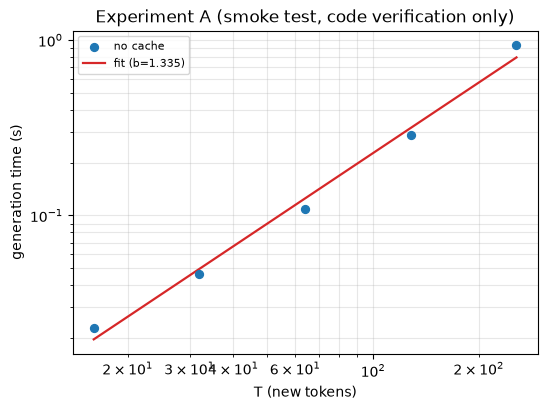

In [15]:
# --- 実験 A: べき乗則あてはめと判定 ---
_a_y_nocache = [float(np.mean(experiment_a_raw["nocache"][t])) for t in A_T_LEVELS]
_a_y_cache = [float(np.mean(experiment_a_raw["cache"][t])) for t in A_T_LEVELS]

experiment_a_fit_nocache = fit_power_law_exponent(A_T_LEVELS, _a_y_nocache)
experiment_a_fit_cache = fit_power_law_exponent(A_T_LEVELS, _a_y_cache)
print(f"b(キャッシュなし) = {experiment_a_fit_nocache.exponent:.4f} "
      f"+- {experiment_a_fit_nocache.exponent_stderr:.4f}")
print(f"b(キャッシュあり) = {experiment_a_fit_cache.exponent:.4f} "
      f"+- {experiment_a_fit_cache.exponent_stderr:.4f}")

_a_delta_b = experiment_a_fit_nocache.exponent - experiment_a_fit_cache.exponent
_a_sigma_delta_b = float(
    np.sqrt(experiment_a_fit_nocache.exponent_stderr**2 + experiment_a_fit_cache.exponent_stderr**2)
)
print(f"Delta_b = {_a_delta_b:.4f}, sigma_Delta_b = {_a_sigma_delta_b:.4f}, "
      f"Delta_b / sigma = {_a_delta_b / _a_sigma_delta_b:.2f}")

# 診断量: 理論上のべき指数の上限との対比(判定基準ではない)。
print(f"[診断量] 理論上限: キャッシュなし b<=3, キャッシュあり b<=2")

plot_log_log_fit(
    A_T_LEVELS, _a_y_nocache, experiment_a_fit_nocache.exponent, experiment_a_fit_nocache.coefficient,
    label="no cache", xlabel="T (new tokens)", ylabel="generation time (s)",
    title="Experiment A (smoke test, code verification only)",
)
plt.show()
# 本番実行後、このセルの出力(グラフ・数値)を踏まえて 8 節の考察を書く。
# このセル自体はスモークテストの数値であり、判定結果を結論として本文には記述しない。

In [16]:
# --- 実験 A: 本番水準・本番反復回数への外挿(CLAUDE.md 第 1 段階要件 1) ---
# スモークテストのべき乗則あてはめ(t = a * T^b)をそのまま使って本番水準の時間を見積もる。
# 各水準につきウォームアップ 1 回 + PRODUCTION_A_REPEATS 回の呼び出しがある。
_a_calls_per_level = PRODUCTION_A_REPEATS + 1
_a_extrapolated_nocache = sum(
    experiment_a_fit_nocache.coefficient * t**experiment_a_fit_nocache.exponent
    for t in PRODUCTION_A_T_LEVELS
) * _a_calls_per_level
_a_extrapolated_cache = sum(
    experiment_a_fit_cache.coefficient * t**experiment_a_fit_cache.exponent
    for t in PRODUCTION_A_T_LEVELS
) * _a_calls_per_level
EXPERIMENT_A_EXTRAPOLATED_SECONDS = _a_extrapolated_nocache + _a_extrapolated_cache
print(f"外挿: キャッシュなし {_a_extrapolated_nocache:.1f} 秒 + "
      f"キャッシュあり {_a_extrapolated_cache:.1f} 秒 = "
      f"{EXPERIMENT_A_EXTRAPOLATED_SECONDS:.1f} 秒"
      f"(水準 {PRODUCTION_A_T_LEVELS}、水準あたり {_a_calls_per_level} 回)")

外挿: キャッシュなし 230.5 秒 + キャッシュあり 40.8 秒 = 271.3 秒(水準 [128, 256, 512, 1024, 2048]、水準あたり 11 回)


### 7.3 実験 B: prefill と decode のバッチサイズ依存性の差

- **検証すること**: 総実行時間のバッチサイズに対する依存は、decode のほうが
  prefill より弱い(メモリ帯域律速の署名)。
- **対比量**: $\Delta b_B = b_{\text{decode}}(B) - b_{\text{prefill}}(B)$。
  $b(B)$ は総実行時間のバッチサイズ $B$ に対するべき指数。
  - **介入の直接作用点**: バッチサイズ $B$ が直接作用するのは 1 回の行列演算の
    形状(3.3 節の $N = B \cdot S$)であり、対比量($b(B)$)はこの演算を 1 回
    実行した総時間から求める。prefill・decode いずれも「1 回の呼び出し」を
    そのまま計測するため、作用点との距離は小さい。
- **判定基準**: $\Delta b_B < -2\sigma_{\Delta b_B}$ なら支持、$>
  +2\sigma_{\Delta b_B}$ なら反証、それ以外は判定不能。標準偏差の導出は実験 A と同じ
  (`fit_power_law_exponent`の`exponent_stderr`を誤差伝播で合成)。
- **水準**: バッチサイズを等比の刻みで 5 点、各点 5 回の反復計測。
- **前提条件 P1_B**: 全バッチサイズで out-of-memory が発生しないこと。
- **診断量**(判定基準は設けない): 演算強度の理論値(3.3 節)、および重み
  読み出しバイト数を T4 GPU の公称メモリ帯域で割った下限時間との比。**この絶対値の
  一致は判定基準にしない**(実測の達成帯域は公称値の 7 割前後であり、真偽を
  判定できる形になりません)。

In [17]:
# --- 実験 B ---
B_LEVELS = [1, 2, 4, 8, 16]  # 等比刻み(smoke)。バッチサイズを縮小してもこの実験の
# 計算量は十分小さいため、prefill 長は縮小せず本番と一致させる(条件間で厳密に
# 一致させる設計の値は縮小後も一致させる、という縮小規則に沿う。プロンプト A の
# レビューで、prefill 長を縮小したまま本番バッチサイズへ外挿すると、prefill の
# 1 回あたりコスト(B * S * d_model * (d_model + S) に比例)のうち S の効果が
# 外挿から抜け落ちることが判明したため、この節で修正した)。
B_REPEATS = 7
PRODUCTION_B_LEVELS = [1, 4, 16, 64, 256]
PRODUCTION_B_REPEATS = 15
PRODUCTION_B_PREFILL_LEN = 512
B_PREFILL_LEN = PRODUCTION_B_PREFILL_LEN

B_OOM_LEVELS: list[int] = []  # out-of-memory で前提不成立となりスキップした水準


def time_prefill(model, batch_size, seq_len, repeats, device):
    times = []
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, seq_len), device=device)
    with torch.no_grad():
        model(x)
        sync(device)
    for _ in range(repeats):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, seq_len), device=device)
        sync(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            model(x)
        sync(device)
        times.append(time.perf_counter() - t0)
    return times


def time_decode_step(model, batch_size, prefill_len, repeats, device):
    times = []
    for _ in range(repeats):
        kv_cache = KeyValueCache(PROD_CONFIG["num_layers"])
        context = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, prefill_len), device=device)
        positions = torch.arange(prefill_len, device=device)
        with torch.no_grad():
            model(context, positions=positions, kv_cache=kv_cache)
        next_token = torch.randint(0, PROD_CONFIG["vocabulary_size"], (batch_size, 1), device=device)
        step_pos = torch.tensor([kv_cache.length], device=device)
        sync(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            model(next_token, positions=step_pos, kv_cache=kv_cache)
        sync(device)
        times.append(time.perf_counter() - t0)
    return times


experiment_b_raw: dict[str, dict[int, list[float]]] = {"prefill": {}, "decode": {}}
for _b in B_LEVELS:
    try:
        _prefill_times = time_prefill(timing_model_a, _b, B_PREFILL_LEN, B_REPEATS, TIMING_DEVICE)
        _decode_times = time_decode_step(timing_model_a, _b, B_PREFILL_LEN, B_REPEATS, TIMING_DEVICE)
    except RuntimeError as e:
        if not is_oom_error(e):
            raise
        B_OOM_LEVELS.append(_b)
        print(f"[前提不成立] B={_b} で out-of-memory が発生したためこの水準をスキップする: {e}")
        continue
    experiment_b_raw["prefill"][_b] = _prefill_times
    experiment_b_raw["decode"][_b] = _decode_times
    for _cond in ("prefill", "decode"):
        _arr = np.array(experiment_b_raw[_cond][_b])
        print(f"B={_b:3d} {_cond:8s} mean={_arr.mean():.5f}s cv={_arr.std() / _arr.mean():.4f}")

B_P0_OOM_HOLDS = len(B_OOM_LEVELS) == 0
print(f"\n前提条件(全バッチサイズで OOM なし)成立: {B_P0_OOM_HOLDS}"
      f"(OOM が発生した水準: {B_OOM_LEVELS})")
print("\n[判定の一次情報 / experiment_b_raw]")
print(json.dumps(experiment_b_raw, ensure_ascii=False))

B=  1 prefill  mean=0.01338s cv=0.0109
B=  1 decode   mean=0.00128s cv=0.0389


B=  2 prefill  mean=0.02631s cv=0.0093
B=  2 decode   mean=0.00210s cv=0.0221


B=  4 prefill  mean=0.05081s cv=0.0061
B=  4 decode   mean=0.00267s cv=0.0291


B=  8 prefill  mean=0.09993s cv=0.0043
B=  8 decode   mean=0.00367s cv=0.0184


B= 16 prefill  mean=0.19770s cv=0.0057
B= 16 decode   mean=0.00655s cv=0.1354

前提条件(全バッチサイズで OOM なし)成立: True(OOM が発生した水準: [])

[判定の一次情報 / experiment_b_raw]
{"prefill": {"1": [0.013596166973002255, 0.013536665996070951, 0.013198249973356724, 0.013219041982665658, 0.01339787500910461, 0.013251625001430511, 0.013427833968307823], "2": [0.02613399998517707, 0.026063249970320612, 0.026507375005166978, 0.026420834008604288, 0.026194749982096255, 0.026071666041389108, 0.02676799998153001], "4": [0.051408124971203506, 0.05076641699997708, 0.05111329100327566, 0.050750624970532954, 0.05051875003846362, 0.05060924997087568, 0.050507458043284714], "8": [0.09938295802567154, 0.1007476249942556, 0.10004420799668878, 0.09989391698036343, 0.09968158300034702, 0.1002505419892259, 0.09953679196769372], "16": [0.1996144579607062, 0.1990680830203928, 0.1978583749732934, 0.19632720795925707, 0.19695704197511077, 0.19703104201471433, 0.19702679198235273]}, "decode": {"1": [0.0013034579460509121, 0.00138837

最大 CV: 0.1354(全条件: {'prefill_B1': 0.010913311914631307, 'prefill_B2': 0.009343125311034869, 'prefill_B4': 0.006097103667015073, 'prefill_B8': 0.00431408528278585, 'prefill_B16': 0.00570325374622026, 'decode_B1': 0.038878332907142384, 'decode_B2': 0.022057110379718557, 'decode_B4': 0.02910537907684151, 'decode_B8': 0.018362236154953294, 'decode_B16': 0.13543018015463656})
P0(CV <= 0.1)成立: False
b(prefill) = 0.9697 +- 0.0033
b(decode)  = 0.5510 +- 0.0463
Delta_b_B = -0.4187, sigma = 0.0464, Delta_b_B / sigma = -9.02
[診断量] decode 1 層あたりの演算強度(概算): 0.496 FLOPs/byte


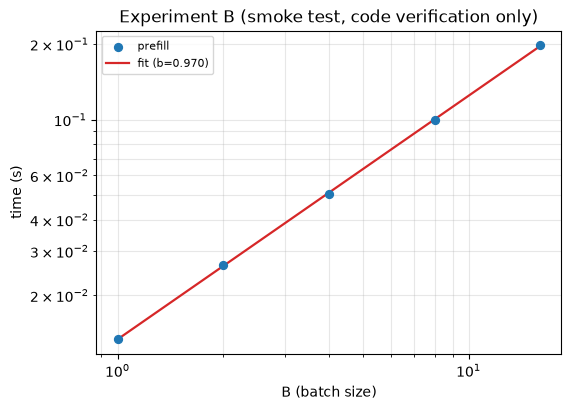

In [18]:
_b_successful_levels = [b for b in B_LEVELS if b not in B_OOM_LEVELS]
_b_cv_by_condition = {
    f"{cond}_B{b}": float(np.std(vals) / np.mean(vals))
    for cond, by_b in experiment_b_raw.items()
    for b, vals in by_b.items()
}
_b_max_cv = max(_b_cv_by_condition.values())
print(f"最大 CV: {_b_max_cv:.4f}(全条件: {_b_cv_by_condition})")
B_P0_HOLDS = _b_max_cv <= 0.1
print(f"P0(CV <= 0.1)成立: {B_P0_HOLDS}")

_b_y_prefill = [float(np.mean(experiment_b_raw["prefill"][b])) for b in _b_successful_levels]
_b_y_decode = [float(np.mean(experiment_b_raw["decode"][b])) for b in _b_successful_levels]
experiment_b_fit_prefill = fit_power_law_exponent(_b_successful_levels, _b_y_prefill)
experiment_b_fit_decode = fit_power_law_exponent(_b_successful_levels, _b_y_decode)
print(f"b(prefill) = {experiment_b_fit_prefill.exponent:.4f} +- {experiment_b_fit_prefill.exponent_stderr:.4f}")
print(f"b(decode)  = {experiment_b_fit_decode.exponent:.4f} +- {experiment_b_fit_decode.exponent_stderr:.4f}")

_b_delta_b = experiment_b_fit_decode.exponent - experiment_b_fit_prefill.exponent
_b_sigma_delta_b = float(
    np.sqrt(experiment_b_fit_decode.exponent_stderr**2 + experiment_b_fit_prefill.exponent_stderr**2)
)
print(f"Delta_b_B = {_b_delta_b:.4f}, sigma = {_b_sigma_delta_b:.4f}, "
      f"Delta_b_B / sigma = {_b_delta_b / _b_sigma_delta_b:.2f}")

# 診断量: 演算強度の理論値、T4 公称帯域からの下限時間との比(判定基準ではない)。
_b_d_model = PROD_CONFIG["d_model"]
_b_weight_bytes = _b_d_model * _b_d_model * 4
_b_decode_ai = compute_arithmetic_intensity(2 * 1 * _b_d_model * _b_d_model, _b_weight_bytes + 1 * 2 * _b_d_model * 4)
print(f"[診断量] decode 1 層あたりの演算強度(概算): {_b_decode_ai:.3f} FLOPs/byte")

plot_log_log_fit(
    _b_successful_levels, _b_y_prefill, experiment_b_fit_prefill.exponent, experiment_b_fit_prefill.coefficient,
    label="prefill", xlabel="B (batch size)", ylabel="time (s)",
    title="Experiment B (smoke test, code verification only)",
)
plt.show()

In [19]:
# --- 実験 B: 本番水準への外挿(CLAUDE.md 第 1 段階要件 1) ---
_b_calls_per_level = PRODUCTION_B_REPEATS + 1  # ウォームアップ 1 回を含む
_b_extrapolated_prefill = sum(
    experiment_b_fit_prefill.coefficient * b**experiment_b_fit_prefill.exponent
    for b in PRODUCTION_B_LEVELS
) * _b_calls_per_level
_b_extrapolated_decode = sum(
    experiment_b_fit_decode.coefficient * b**experiment_b_fit_decode.exponent
    for b in PRODUCTION_B_LEVELS
) * _b_calls_per_level
EXPERIMENT_B_EXTRAPOLATED_SECONDS = _b_extrapolated_prefill + _b_extrapolated_decode
print(f"外挿: prefill {_b_extrapolated_prefill:.1f} 秒 + decode {_b_extrapolated_decode:.1f} 秒 = "
      f"{EXPERIMENT_B_EXTRAPOLATED_SECONDS:.1f} 秒"
      f"(水準 {PRODUCTION_B_LEVELS}、水準あたり {_b_calls_per_level} 回)")

外挿: prefill 62.5 秒 + decode 0.8 秒 = 63.3 秒(水準 [1, 4, 16, 64, 256]、水準あたり 16 回)


In [20]:
# --- 実験 B: 本番水準での必要メモリ量の閉形式による見積もり(較正は本番と同じ
# スケールで行うという規約に従い、閉形式で計算できる量は本番実行時まで未知にしない) ---
T4_MEMORY_BYTES = 16 * (1024**3)  # T4 GPU の公称メモリ容量(16 GB)

_b_prod_attention_score_bytes_per_layer = (
    PRODUCTION_B_LEVELS[-1] * PROD_CONFIG["num_heads"] * PRODUCTION_B_PREFILL_LEN**2 * 4
)
_b_prod_attention_score_bytes_total = _b_prod_attention_score_bytes_per_layer * PROD_CONFIG["num_layers"]
print(
    f"本番水準(batch_size={PRODUCTION_B_LEVELS[-1]}, prefill_len={PRODUCTION_B_PREFILL_LEN})での"
    f"Attention スコア行列のメモリ量:"
)
print(f"  1 層あたり: {_b_prod_attention_score_bytes_per_layer / 1e9:.2f} GB")
print(f"  {PROD_CONFIG['num_layers']} 層合計: {_b_prod_attention_score_bytes_total / 1e9:.2f} GB")
print(f"  T4 GPU 容量(16 GB)に対する比率: {_b_prod_attention_score_bytes_total / T4_MEMORY_BYTES:.1%}")
if _b_prod_attention_score_bytes_total > T4_MEMORY_BYTES:
    print("[警告] Attention スコア行列だけで T4 GPU の容量を超える。"
          "PRODUCTION_B_LEVELS の見直しが必要。")
else:
    print("[OK] Attention スコア行列のメモリ量は T4 GPU の容量に収まる見込み"
          "(重み・活性化・オプティマイザ状態は含まない概算であることに注意)。")

本番水準(batch_size=256, prefill_len=512)でのAttention スコア行列のメモリ量:
  1 層あたり: 2.15 GB
  4 層合計: 8.59 GB
  T4 GPU 容量(16 GB)に対する比率: 50.0%
[OK] Attention スコア行列のメモリ量は T4 GPU の容量に収まる見込み(重み・活性化・オプティマイザ状態は含まない概算であることに注意)。


### 7.4 実験 C: Key / Value ヘッド数の削減による高速化の系列長依存性

- **検証すること**: Key / Value ヘッド数の削減による decode の高速化は、
  系列長が長いほど大きい。
- **対比量**: $r(T) = t_{g=h}(T) / t_{g=1}(T)$($t_{g=h}$ は通常の多頭注意機構
  ($g=h$)の生成時間、$t_{g=1}$ は MQA($g=1$)の生成時間)としたときの
  $\Delta r = r(T_{\max}) - r(T_{\min})$。$T_{\min}$・$T_{\max}$ は等比の刻みの
  両端とする。
  - **介入の直接作用点**: Key / Value ヘッド数の削減が直接作用するのは、
    1 decode ステップあたりの KV キャッシュの読み出しバイト数(3.2・3.4 節)
    である。対比量 $r(T)$ は「生成全体の時間比」という下流の量であり、direct な
    作用点(1 ステップの読み出しバイト数)からは 1 段階離れている(生成全体の
    時間には、Key/Value 削減の影響を受けない Query 射影・出力射影・
    Feed-Forward Network の計算も含まれるため)。
- **判定基準**: $\Delta r > 2\sigma_{\Delta r}$ なら支持、$< -2\sigma_{\Delta r}$
  なら反証、それ以外は判定不能。$\sigma_{\Delta r}$ は反復計測から誤差伝播で
  導く。$r = a/b$(比)の相対標準誤差は、$a$・$b$ それぞれの相対標準誤差の
  二乗和の平方根

  $$
  \frac{\sigma_r}{r} = \sqrt{\left(\frac{\sigma_a / \sqrt{n}}{a}\right)^2
      + \left(\frac{\sigma_b / \sqrt{n}}{b}\right)^2}
  $$

  で求め($\sigma_a$・$\sigma_b$ は反復計測の標本標準偏差、$n$ は反復回数)、
  $T_{\min}$・$T_{\max}$ それぞれで得た $\sigma_{r(T_{\min})}$・
  $\sigma_{r(T_{\max})}$ を $\sigma_{\Delta r} = \sqrt{\sigma_{r(T_{\min})}^2
  + \sigma_{r(T_{\max})}^2}$ として合成する。
- この実験は学習を伴わない。重みはランダム初期化でよく、Key / Value ヘッド数だけが
  異なる同一構成のモデルで計測する。

In [21]:
# --- 実験 C ---
C_T_SMALL, C_T_LARGE = 16, 256  # 等比刻みの両端(smoke)
C_REPEATS = 7
C_PROMPT_LENGTH = 4
PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE = 64, 4096
PRODUCTION_C_REPEATS = 15

timing_model_mqa_c = convert_attention_to_grouped_query(
    timing_model_a, num_key_value_heads=1, init="random", seed=0
).to(TIMING_DEVICE)
timing_model_mqa_c.eval()


def time_decode_generate(model, t_new_tokens, repeats, prompt_length, device):
    assert prompt_length + t_new_tokens <= model.max_sequence_length, (
        f"prompt_length({prompt_length}) + t_new_tokens({t_new_tokens}) が "
        f"model.max_sequence_length({model.max_sequence_length}) を超えている"
    )
    times = []
    x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
    with torch.no_grad():
        model.generate(x.clone(), max_new_tokens=t_new_tokens, temperature=0.0, use_cache=True)
        sync(device)
    for _ in range(repeats):
        x = torch.randint(0, PROD_CONFIG["vocabulary_size"], (1, prompt_length), device=device)
        sync(device)
        t0 = time.perf_counter()
        with torch.no_grad():
            model.generate(x, max_new_tokens=t_new_tokens, temperature=0.0, use_cache=True)
        sync(device)
        times.append(time.perf_counter() - t0)
    return times


experiment_c_raw = {
    "full_small": time_decode_generate(timing_model_a, C_T_SMALL, C_REPEATS, C_PROMPT_LENGTH, TIMING_DEVICE),
    "mqa_small": time_decode_generate(timing_model_mqa_c, C_T_SMALL, C_REPEATS, C_PROMPT_LENGTH, TIMING_DEVICE),
    "full_large": time_decode_generate(timing_model_a, C_T_LARGE, C_REPEATS, C_PROMPT_LENGTH, TIMING_DEVICE),
    "mqa_large": time_decode_generate(timing_model_mqa_c, C_T_LARGE, C_REPEATS, C_PROMPT_LENGTH, TIMING_DEVICE),
}
for _name, _vals in experiment_c_raw.items():
    _arr = np.array(_vals)
    print(f"{_name:12s} mean={_arr.mean():.5f}s cv={_arr.std() / _arr.mean():.4f}")

print("\n[判定の一次情報 / experiment_c_raw]")
print(json.dumps(experiment_c_raw, ensure_ascii=False))

full_small   mean=0.01403s cv=0.0097
mqa_small    mean=0.01333s cv=0.0063
full_large   mean=0.26466s cv=0.2290
mqa_large    mean=0.23242s cv=0.0470

[判定の一次情報 / experiment_c_raw]
{"full_small": [0.014269582985434681, 0.014101415988989174, 0.013930417015217245, 0.013852958043571562, 0.014121291984338313, 0.013897125027142465, 0.014063790964428335], "mqa_small": [0.013322458020411432, 0.013216249994002283, 0.013442041992675513, 0.013382749981246889, 0.013396791997365654, 0.013199874956626445, 0.013317124976310879], "full_large": [0.23958383302669972, 0.23830924998037517, 0.2392242499627173, 0.2391047499841079, 0.2427393749821931, 0.24058016698108986, 0.41308054100954905], "mqa_large": [0.2573150839889422, 0.23494399996707216, 0.23191958299139515, 0.22961249999934807, 0.22606666601495817, 0.2245526670012623, 0.2225266249733977]}


In [22]:
_c_cv_by_condition = {
    name: float(np.std(v) / np.mean(v)) for name, v in experiment_c_raw.items()
}
_c_max_cv = max(_c_cv_by_condition.values())
print(f"最大 CV: {_c_max_cv:.4f}(全条件: {_c_cv_by_condition})")
C_P0_HOLDS = _c_max_cv <= 0.1
print(f"P0(CV <= 0.1)成立: {C_P0_HOLDS}")

_c_full_small = np.array(experiment_c_raw["full_small"])
_c_mqa_small = np.array(experiment_c_raw["mqa_small"])
_c_full_large = np.array(experiment_c_raw["full_large"])
_c_mqa_large = np.array(experiment_c_raw["mqa_large"])


def _relative_stderr(arr: np.ndarray) -> float:
    return float((arr.std(ddof=1) / np.sqrt(len(arr))) / arr.mean())


r_small = float(_c_full_small.mean() / _c_mqa_small.mean())
r_large = float(_c_full_large.mean() / _c_mqa_large.mean())
delta_r = r_large - r_small

sigma_r_small = r_small * np.sqrt(_relative_stderr(_c_full_small) ** 2 + _relative_stderr(_c_mqa_small) ** 2)
sigma_r_large = r_large * np.sqrt(_relative_stderr(_c_full_large) ** 2 + _relative_stderr(_c_mqa_large) ** 2)
sigma_delta_r = float(np.sqrt(sigma_r_small**2 + sigma_r_large**2))

print(f"r(T={C_T_SMALL}) = {r_small:.4f}, r(T={C_T_LARGE}) = {r_large:.4f}")
print(f"Delta_r = {delta_r:.4f}, sigma_Delta_r = {sigma_delta_r:.4f}, "
      f"Delta_r / sigma = {delta_r / sigma_delta_r:.2f}")

最大 CV: 0.2290(全条件: {'full_small': 0.009740156744617723, 'mqa_small': 0.006325860890873454, 'full_large': 0.22899819853941697, 'mqa_large': 0.04697504398685198})
P0(CV <= 0.1)成立: False
r(T=16) = 1.0532, r(T=256) = 1.1387
Delta_r = 0.0856, sigma_Delta_r = 0.1088, Delta_r / sigma = 0.79


In [23]:
# --- 実験 C: 本番水準への外挿(CLAUDE.md 第 1 段階要件 1) ---
# 実験 C 自体は T が 2 点(smoke)のみで独自にべき乗則をあてはめるには点数が足りない。
# 実験 C が測るのは実験 A の「キャッシュあり」と同じ計測(KV キャッシュを用いた
# generate())であるため、実験 A で得たべき乗則あてはめ(experiment_a_fit_cache)を
# 流用して T_min・T_max での時間を外挿する。
_c_calls_per_level = PRODUCTION_C_REPEATS + 1  # ウォームアップ 1 回を含む
_c_extrapolated_per_level = sum(
    experiment_a_fit_cache.coefficient * t**experiment_a_fit_cache.exponent
    for t in (PRODUCTION_C_T_SMALL, PRODUCTION_C_T_LARGE)
)
EXPERIMENT_C_EXTRAPOLATED_SECONDS = _c_extrapolated_per_level * _c_calls_per_level * 2  # 多頭注意機構・MQA の 2 条件
print(f"外挿: T={PRODUCTION_C_T_SMALL}・{PRODUCTION_C_T_LARGE} x 2 条件"
      f"(多頭注意機構・MQA) x {_c_calls_per_level} 回 = "
      f"{EXPERIMENT_C_EXTRAPOLATED_SECONDS:.1f} 秒"
      "(実験 A のキャッシュありのべき乗則あてはめを流用)")

外挿: T=64・4096 x 2 条件(多頭注意機構・MQA) x 16 回 = 128.3 秒(実験 A のキャッシュありのべき乗則あてはめを流用)


### 7.5 実験 D: GQA への変換における平均プール初期化の効果

- **検証すること**: 多頭注意機構から GQA へ変換する際、平均プール初期化は
  ランダム初期化より、同一の追加学習ステップ数で低い bits-per-byte に到達する。
- **条件(主判定)**: GQA・平均プール初期化 + 追加学習 / GQA・ランダム初期化 +
  追加学習。この 2 条件は非埋め込みパラメータ数が完全に一致する(6 節で確認済み)。
- **条件(診断量)**: 元の多頭注意機構チェックポイント(追加学習なし)、
  MQA・平均プール初期化 + 追加学習。多頭注意機構との比較は Key / Value 射影の
  縮小により非埋め込みパラメータ数が揃わないため、**揃えられないことをここに
  明記したうえで参考値として報告する**。
- **Key / Value ヘッド数**: 元モデルのヘッド数 $h=8$ に対し、GQA は $g=4$、MQA は
  $g=1$。
- **対比量**: $\Delta\mathrm{bpb} = \mathrm{bpb}_{\text{random}} -
  \mathrm{bpb}_{\text{mean pool}}$($\mathrm{bpb}_{\text{random}}$ はランダム初期化、
  $\mathrm{bpb}_{\text{mean pool}}$ は平均プール初期化。いずれもシード平均、
  最終ステップの値)。
  - **介入の直接作用点**: この介入(初期化方式)が直接作用するのは初期化直後の
    重み(および、そこから計算される初期化直後の bits-per-byte)である。対比量は
    そこから追加学習を経た下流の量であり、直接の作用点からは 1 段階以上離れて
    いる。この距離を埋めるため、**初期化直後(追加学習ステップ数 0)の
    bits-per-byte を診断量として併記する**。
- **判定基準**: $\Delta\mathrm{bpb} > 2\sigma_{\Delta\mathrm{bpb}}$ なら支持、
  $< -2\sigma_{\Delta\mathrm{bpb}}$ なら反証、それ以外は判定不能。
  $\sigma_{\Delta\mathrm{bpb}} = \sqrt{\sigma_{\text{random}}^2/n +
  \sigma_{\text{mean pool}}^2/n}$($\sigma_{\text{random}}$・$\sigma_{\text{mean pool}}$
  は各条件のシード間標準偏差)、$n$ はシード数(3)。
- **前提条件**:
  - P1: 読み込んだ元チェックポイントの bits-per-byte が 008 の記録値(1.6622、
    008 8.1 節)と相対誤差 1% 以内で一致すること。
  - P2: 全条件で追加学習が実際に進んでいること。単一ステップの訓練損失は
    ミニバッチの引きによる雑音が大きいため(1 ステップだけの比較では、シードに
    よる違いが学習の進行ではなく最初のバッチの引きを反映してしまう)、**最初の
    数ステップの平均訓練損失と最後の数ステップの平均訓練損失を比較する**
    (`P2_AVERAGING_WINDOW`ステップ分の平均、最後の平均が最初の平均より低ければ
    進行とみなす)。
- **モデル**: `kojikojiprg/ai-theories-small-gpt-en`を起点とする(5.3 節で
  読み込み済み)。トークナイザは`kojikojiprg/ai-theories-tokenizer-en`
  (同梱されていないため)。
- **追加学習の最適化手法**: 007 で導入した AdamW・warmup + cosine スケジュールでは
  なく、006 と同じ Adam・固定学習率(3e-4)を使う。少数ステップの追加学習
  (uptraining)であり、両条件(平均プール初期化・ランダム初期化)に同一の
  最適化設定を等しく適用するため、この選択自体は対比量の成立に影響しない。
- **評価**: 006 の`evaluate_bits_per_byte()`と非重複の評価窓を用いる。
  `d_eval_text`(5.3 節)は`train_text`の内側から切り出した held-out スライスで
  あり、`val_text_008`(008 の検証集合、P1 の検証に使う)とも
  `d_train_text`(この実験の追加学習データ)とも重複しない。全条件で評価集合
  (`_full_eval_windows`)・追加学習ステップ数が完全に同一であることをアサーションで
  確認する。
  - **主判定への影響なし、診断量は楽観的に出ることの明記**: `d_eval_text`は
    `train_text`(008 が`base_model`の学習に使ったデータ)の内側から切り出した
    スライスであり、`base_model`は既に`d_eval_text`の内容を学習時に見ている。
    主判定(平均プール初期化 対 ランダム初期化)は両条件で評価集合が同一であり
    この影響は相殺されるため結論に影響しない。一方、診断量である
    初期化直後の bits-per-byte、および`D_ORIGINAL_BPB`(元の多頭注意機構
    チェックポイントの`d_eval_text`上の bits-per-byte)は、真に未知のテキストで
    評価した場合より **楽観的(低い)値** になっている可能性が高い。これらの
    診断量の絶対値に基づく主張はしない。

In [24]:
# --- 実験 D: 前提条件 P1(元チェックポイントの品質確認) ---
_p1_val_ids = encode_corpus(tokenizer, val_text_008)
_p1_eval_windows, _p1_eval_mask = make_evaluation_windows(_p1_val_ids, PROD_CONFIG["sequence_length"])
_p1_eval_bytes = len(val_text_008.encode("utf-8"))
D_P1_BPB = evaluate_bits_per_byte(base_model, _p1_eval_windows, _p1_eval_mask, _p1_eval_bytes, DEVICE, batch_size=16)
D_P1_REFERENCE_BPB = 1.6622  # 008 8.1 節の本番実行結果
D_P1_RELATIVE_ERROR = abs(D_P1_BPB - D_P1_REFERENCE_BPB) / D_P1_REFERENCE_BPB
print(f"P1: 元チェックポイントの bits-per-byte = {D_P1_BPB:.4f}"
      f"(008 記録値 {D_P1_REFERENCE_BPB}、相対誤差 {D_P1_RELATIVE_ERROR:.2%})")
D_P1_HOLDS = D_P1_RELATIVE_ERROR <= 0.01
print(f"P1 成立: {D_P1_HOLDS}")

P1: 元チェックポイントの bits-per-byte = 1.6681(008 記録値 1.6622、相対誤差 0.35%)
P1 成立: True


In [25]:
# --- 実験 D: 条件・学習ループの準備 ---
D_NUM_STEPS = 15  # smoke。本番は PRODUCTION_D_NUM_STEPS(5.3 節、300)を使う。
D_BATCH_SIZE = 8
D_SEEDS = [0, 1, 2]

# 全条件で共通の学習・評価データ(5.3 節で構築済み)。評価集合は _full_eval_windows /
# _full_eval_mask / _full_eval_bytes を全条件で共有する(下のアサーションで確認)。
D_TRAIN_TEXT_CHARS = 400_000 if SMOKE_TEST else len(d_train_text)  # 本番は d_train_text 全体
d_train_ids = encode_corpus(tokenizer, d_train_text[:D_TRAIN_TEXT_CHARS])
print(f"d_train_ids: {len(d_train_ids):,} トークン(smoke: 先頭 {D_TRAIN_TEXT_CHARS:,} 文字)")
print(f"評価窓: {_full_eval_windows.shape[0]} 個(全条件で共有)")

# 冗長な再計算の排除(7.6 節で検証): このセルで 1 回だけ符号化した d_train_ids・
# _full_eval_windows・_full_eval_mask を、以降の全条件・全シードの学習・評価ループで
# そのまま参照する(再符号化しない)。その証拠として、基となるメモリ領域のポインタを
# ここで記録しておく。
_d_train_ids_data_ptr_at_creation = d_train_ids.data_ptr()
_d_eval_windows_data_ptr_at_creation = _full_eval_windows.data_ptr()
_d_eval_mask_data_ptr_at_creation = _full_eval_mask.data_ptr()


def build_condition_model(num_key_value_heads: int, init: str, seed: int | None) -> GPTLanguageModel:
    return convert_attention_to_grouped_query(base_model, num_key_value_heads, init, seed=seed)


D_CONDITIONS = ["gqa_mean_pool", "gqa_random", "mqa_mean_pool_diagnostic"]
experiment_d_raw: dict[str, dict[str, list]] = {cond: {"seeds": []} for cond in D_CONDITIONS}

d_train_ids: 93,053 トークン(smoke: 先頭 400,000 文字)
評価窓: 469 個(全条件で共有)


In [26]:
# --- 実験 D: 診断条件(元の多頭注意機構チェックポイント、追加学習なし) ---
D_ORIGINAL_BPB = evaluate_bits_per_byte(
    base_model, _full_eval_windows, _full_eval_mask, _full_eval_bytes, DEVICE, batch_size=16
)
print(f"[診断量] 元の多頭注意機構チェックポイント(追加学習なし)の d_eval_text 上の bpb: "
      f"{D_ORIGINAL_BPB:.4f}")
print("[注記] このモデルは GQA/MQA と非埋め込みパラメータ数が揃わないため、参考値として扱う。")

[診断量] 元の多頭注意機構チェックポイント(追加学習なし)の d_eval_text 上の bpb: 1.3370
[注記] このモデルは GQA/MQA と非埋め込みパラメータ数が揃わないため、参考値として扱う。


In [27]:
# --- 実験 D: 主判定 2 条件 + 診断条件(MQA 平均プール)の学習ループ ---
_d_specs = {
    "gqa_mean_pool": {"num_key_value_heads": 4, "init": "mean_pool"},
    "gqa_random": {"num_key_value_heads": 4, "init": "random"},
    "mqa_mean_pool_diagnostic": {"num_key_value_heads": 1, "init": "mean_pool"},
}

_d_param_counts: dict[str, int] = {}
_d_trained_model_for_upload = None  # gqa_mean_pool, seed 0 を代表チェックポイントとして残す

# 前提条件 P2: 単一ステップの訓練損失は雑音が大きいため、最初と最後の数ステップの
# 平均で比較する(D_NUM_STEPS より大きくならないようにクリップする)。
P2_AVERAGING_WINDOW = min(3, D_NUM_STEPS)

for cond_name, spec in _d_specs.items():
    for seed in D_SEEDS:
        model = build_condition_model(spec["num_key_value_heads"], spec["init"], seed=seed)
        _d_param_counts.setdefault(cond_name, count_non_embedding_parameters(model))

        initial_bpb = evaluate_bits_per_byte(
            model, _full_eval_windows, _full_eval_mask, _full_eval_bytes, DEVICE, batch_size=16
        )
        history = train_language_model(
            model, d_train_ids, _full_eval_windows, _full_eval_mask, _full_eval_bytes,
            num_steps=D_NUM_STEPS, batch_size=D_BATCH_SIZE, sequence_length=PROD_CONFIG["sequence_length"],
            learning_rate=3e-4, eval_interval=D_NUM_STEPS, device=DEVICE, seed=seed,
        )
        final_bpb = history["eval_bits_per_byte"][-1]
        initial_loss_avg = float(np.mean(history["train_loss"][:P2_AVERAGING_WINDOW]))
        final_loss_avg = float(np.mean(history["train_loss"][-P2_AVERAGING_WINDOW:]))
        progressed = final_loss_avg < initial_loss_avg

        experiment_d_raw[cond_name]["seeds"].append({
            "seed": seed,
            "initial_bpb": initial_bpb,
            "final_bpb": final_bpb,
            "initial_train_loss": history["train_loss"][0],
            "final_train_loss": history["train_loss"][-1],
            "initial_train_loss_avg": initial_loss_avg,
            "final_train_loss_avg": final_loss_avg,
            "progressed": progressed,
        })
        print(f"{cond_name} seed={seed}: initial_bpb={initial_bpb:.4f} -> final_bpb={final_bpb:.4f} "
              f"(train_loss_avg(先頭{P2_AVERAGING_WINDOW})={initial_loss_avg:.4f} -> "
              f"train_loss_avg(末尾{P2_AVERAGING_WINDOW})={final_loss_avg:.4f}, progressed={progressed})")

        if cond_name == "gqa_mean_pool" and seed == 0:
            _d_trained_model_for_upload = model

print("\n[判定の一次情報 / experiment_d_raw]")
print(json.dumps(experiment_d_raw, ensure_ascii=False))

gqa_mean_pool seed=0: initial_bpb=2.3261 -> final_bpb=1.8957 (train_loss_avg(先頭3)=6.2155 -> train_loss_avg(末尾3)=4.2918, progressed=True)


gqa_mean_pool seed=1: initial_bpb=2.3261 -> final_bpb=1.9070 (train_loss_avg(先頭3)=5.6039 -> train_loss_avg(末尾3)=4.5420, progressed=True)


gqa_mean_pool seed=2: initial_bpb=2.3261 -> final_bpb=1.9064 (train_loss_avg(先頭3)=5.9205 -> train_loss_avg(末尾3)=4.4039, progressed=True)


gqa_random seed=0: initial_bpb=3.3507 -> final_bpb=2.9590 (train_loss_avg(先頭3)=8.9930 -> train_loss_avg(末尾3)=7.3249, progressed=True)


gqa_random seed=1: initial_bpb=3.2944 -> final_bpb=2.9727 (train_loss_avg(先頭3)=9.0097 -> train_loss_avg(末尾3)=7.3908, progressed=True)


gqa_random seed=2: initial_bpb=3.3171 -> final_bpb=3.0146 (train_loss_avg(先頭3)=9.2072 -> train_loss_avg(末尾3)=7.4050, progressed=True)


mqa_mean_pool_diagnostic seed=0: initial_bpb=3.3982 -> final_bpb=2.9016 (train_loss_avg(先頭3)=9.0630 -> train_loss_avg(末尾3)=6.8726, progressed=True)


mqa_mean_pool_diagnostic seed=1: initial_bpb=3.3982 -> final_bpb=2.8712 (train_loss_avg(先頭3)=8.8695 -> train_loss_avg(末尾3)=6.9494, progressed=True)


mqa_mean_pool_diagnostic seed=2: initial_bpb=3.3982 -> final_bpb=2.8946 (train_loss_avg(先頭3)=9.0996 -> train_loss_avg(末尾3)=6.8153, progressed=True)

[判定の一次情報 / experiment_d_raw]
{"gqa_mean_pool": {"seeds": [{"seed": 0, "initial_bpb": 2.3261236092861584, "final_bpb": 1.8957448638692567, "initial_train_loss": 6.591773509979248, "final_train_loss": 3.94270658493042, "initial_train_loss_avg": 6.215541044871013, "final_train_loss_avg": 4.291840394337972, "progressed": true}, {"seed": 1, "initial_bpb": 2.3261236092861584, "final_bpb": 1.9069675837453393, "initial_train_loss": 6.204634666442871, "final_train_loss": 4.6641998291015625, "initial_train_loss_avg": 5.6039449373881025, "final_train_loss_avg": 4.541958014170329, "progressed": true}, {"seed": 2, "initial_bpb": 2.3261236092861584, "final_bpb": 1.9063524986878637, "initial_train_loss": 6.3402814865112305, "final_train_loss": 5.297509670257568, "initial_train_loss_avg": 5.920543829600017, "final_train_loss_avg": 4.403888702392578, "prog

In [28]:
# --- 実験 D: 不変条件 P2(全条件で追加学習が実際に進んでいること) ---
D_P2_HOLDS = all(
    run["progressed"] for cond in D_CONDITIONS for run in experiment_d_raw[cond]["seeds"]
)
print(f"P2(全条件で末尾{P2_AVERAGING_WINDOW}ステップ平均損失 < 先頭{P2_AVERAGING_WINDOW}ステップ平均損失)成立: {D_P2_HOLDS}")

# --- 不変条件: 実験 D の主判定 2 条件で非埋め込みパラメータ数が完全一致すること ---
assert _d_param_counts["gqa_mean_pool"] == _d_param_counts["gqa_random"], (
    "実験 D の主判定条件で非埋め込みパラメータ数が一致しない"
)
print(f"[OK] 主判定条件の非埋め込みパラメータ数が一致: {_d_param_counts['gqa_mean_pool']:,}")

P2(全条件で末尾3ステップ平均損失 < 先頭3ステップ平均損失)成立: True
[OK] 主判定条件の非埋め込みパラメータ数が一致: 2,886,912


In [29]:
# --- 実験 D: 対比量の計算 ---
_d_mean_final = np.array([r["final_bpb"] for r in experiment_d_raw["gqa_mean_pool"]["seeds"]])
_d_random_final = np.array([r["final_bpb"] for r in experiment_d_raw["gqa_random"]["seeds"]])
_d_mean_initial = np.array([r["initial_bpb"] for r in experiment_d_raw["gqa_mean_pool"]["seeds"]])
_d_random_initial = np.array([r["initial_bpb"] for r in experiment_d_raw["gqa_random"]["seeds"]])

n_seeds = len(D_SEEDS)
delta_bpb = float(_d_random_final.mean() - _d_mean_final.mean())
sigma_delta_bpb = float(
    np.sqrt(_d_random_final.std(ddof=1) ** 2 / n_seeds + _d_mean_final.std(ddof=1) ** 2 / n_seeds)
)
print(f"Delta_bpb(最終) = {delta_bpb:.4f}, sigma = {sigma_delta_bpb:.4f}, "
      f"Delta_bpb / sigma = {delta_bpb / sigma_delta_bpb:.2f}" if sigma_delta_bpb > 0 else "sigma=0")

# 診断量: 初期化直後(追加学習ステップ数 0)の bpb(介入の直接作用点)。
print(f"\n[診断量] 初期化直後の bpb: mean_pool={_d_mean_initial.mean():.4f} "
      f"(seed毎={_d_mean_initial.tolist()}), random={_d_random_initial.mean():.4f} "
      f"(seed毎={_d_random_initial.tolist()})")

_d_mqa_final = np.array([r["final_bpb"] for r in experiment_d_raw["mqa_mean_pool_diagnostic"]["seeds"]])
print(f"[診断量] MQA・平均プール初期化 + 追加学習の最終 bpb(seed平均): {_d_mqa_final.mean():.4f}"
      "(多頭注意機構と非埋め込みパラメータ数が揃わないため参考値)")

Delta_bpb(最終) = 1.0791, sigma = 0.0171, Delta_bpb / sigma = 63.06

[診断量] 初期化直後の bpb: mean_pool=2.3261 (seed毎=[2.3261236092861584, 2.3261236092861584, 2.3261236092861584]), random=3.3208 (seed毎=[3.3507134120703728, 3.294403090067525, 3.317141630801045])
[診断量] MQA・平均プール初期化 + 追加学習の最終 bpb(seed平均): 2.8891(多頭注意機構と非埋め込みパラメータ数が揃わないため参考値)


### 7.6 外挿値の合計とセッション予算との比較

5.3 節(符号化・追加学習・評価)の小計に、実験 A・B・C 自身の時間計測の外挿値を
合算し、セッション予算との比較を確定させる(CLAUDE.md 第 1 段階要件 1)。

**この外挿値の絶対値はデバイス依存であることに注意する。** 5.3 節は`DEVICE`
(ローカルでは MPS)、実験 A・B・C は`TIMING_DEVICE`(ローカルでは CPU)で測った
係数を、本番の Google Colab T4 GPU(CUDA)にそのまま適用している。べき乗則の
**指数** はハードウェアが変わってもある程度は保たれると期待できるが、**係数**
(1 回あたりの絶対時間)はデバイスによって大きく異なる。特に実験 C は本番で
decode ステップが延べ約 13 万回(`PRODUCTION_C_REPEATS` x 2 条件 x
(`PRODUCTION_C_T_SMALL` + `PRODUCTION_C_T_LARGE`))に達し、T4 GPU では
1 ステップあたりのカーネル起動オーバーヘッド(CPU 実行にはない要素)が支配項に
なりうる。したがって、以下の外挿値の合計は **セッション予算に収まるかどうかの
目安** として使い、本番実行後の実測値で必ず更新すること(この後の実験セルの
再実行や再計測は求めない。8 節の考察執筆時に、実際にかかった時間をあわせて
記録すればよい)。

In [30]:
TOTAL_EXTRAPOLATED_SECONDS = (
    _subtotal_5_3_seconds
    + EXPERIMENT_A_EXTRAPOLATED_SECONDS
    + EXPERIMENT_B_EXTRAPOLATED_SECONDS
    + EXPERIMENT_C_EXTRAPOLATED_SECONDS
)
print(f"5.3 節(符号化・追加学習・評価)小計: {_subtotal_5_3_seconds:.1f} 秒")
print(f"実験 A: {EXPERIMENT_A_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"実験 B: {EXPERIMENT_B_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"実験 C: {EXPERIMENT_C_EXTRAPOLATED_SECONDS:.1f} 秒")
print(f"合計: {TOTAL_EXTRAPOLATED_SECONDS:.1f} 秒 / セッション予算: {SESSION_BUDGET_SECONDS} 秒")
if TOTAL_EXTRAPOLATED_SECONDS > SESSION_BUDGET_SECONDS:
    print("[警告] 外挿値の合計がセッション予算を超える。本番実行前にステップ数・水準数の見直しが必要。")
else:
    print("[OK] 外挿値の合計はセッション予算に対して十分な余裕がある。")

5.3 節(符号化・追加学習・評価)小計: 244.4 秒
実験 A: 271.3 秒
実験 B: 63.3 秒
実験 C: 128.3 秒
合計: 707.3 秒 / セッション予算: 7200 秒
[OK] 外挿値の合計はセッション予算に対して十分な余裕がある。


### 7.7 冗長な再計算の排除の確認

`d_train_ids`・`_full_eval_windows`・`_full_eval_mask`は 5.3 節で 1 回だけ符号化し、
実験 D の条件 x シードの全 9 回の学習・評価ループでそのまま再利用した(再符号化して
いない)。基となるメモリ領域のポインタ(`Tensor.data_ptr()`)が、5.3 節での作成時と
実験 D のループを終えた現在とで一致することを確認する。

In [31]:
assert d_train_ids.data_ptr() == _d_train_ids_data_ptr_at_creation, (
    "d_train_ids が実験 D のループ中に再代入・再符号化された可能性がある"
)
assert _full_eval_windows.data_ptr() == _d_eval_windows_data_ptr_at_creation
assert _full_eval_mask.data_ptr() == _d_eval_mask_data_ptr_at_creation
print("[OK] d_train_ids・_full_eval_windows・_full_eval_mask は、5.3 節で符号化した"
      "同一のメモリ領域を実験 D の全 9 回の学習・評価ループで再利用した"
      "(再符号化・再計算していない)")

[OK] d_train_ids・_full_eval_windows・_full_eval_mask は、5.3 節で符号化した同一のメモリ領域を実験 D の全 9 回の学習・評価ループで再利用した(再符号化・再計算していない)


### 7.8 生データの書き出しと Hugging Face Hub への昇格

判定の一次情報(実験 A・B・C の条件 x 水準 x 反復の生の実行時間、実験 D の条件 x
シードの学習曲線・bits-per-byte)を`.rawdata/010_rawdata.json`に書き出す。
CLAUDE.md「生データの永続化」節に従い、書き出しセルと同じセルで SHA-256・
バイト数・件数を印字し、直後のセルで Google Colab からローカルへのダウンロードを
行う(Google Colab 以外の環境ではスキップする)。

In [32]:
rawdata = {
    "experiment_a": experiment_a_raw,
    "experiment_a_t_levels": A_T_LEVELS,
    "experiment_a_p0_cv_by_condition": _a_cv_by_condition,
    "experiment_a_p0_holds": A_P0_HOLDS,
    "experiment_b": experiment_b_raw,
    "experiment_b_levels": B_LEVELS,
    "experiment_b_oom_levels": B_OOM_LEVELS,
    "experiment_b_p0_cv_by_condition": _b_cv_by_condition,
    "experiment_b_p0_holds": B_P0_HOLDS,
    "experiment_c": experiment_c_raw,
    "experiment_c_t_small_large": [C_T_SMALL, C_T_LARGE],
    "experiment_c_p0_cv_by_condition": _c_cv_by_condition,
    "experiment_c_p0_holds": C_P0_HOLDS,
    "experiment_d": experiment_d_raw,
    "experiment_d_p1_bpb": D_P1_BPB,
    "experiment_d_p1_holds": D_P1_HOLDS,
    "experiment_d_p2_holds": D_P2_HOLDS,
    "experiment_d_original_checkpoint_bpb": D_ORIGINAL_BPB,
}

_rawdata_path = RAWDATA_DIR / "010_rawdata.json"
_rawdata_json = json.dumps(rawdata, ensure_ascii=False, indent=2)
_rawdata_path.write_text(_rawdata_json, encoding="utf-8")

_rawdata_bytes = _rawdata_path.stat().st_size
_rawdata_sha256 = hashlib.sha256(_rawdata_path.read_bytes()).hexdigest()
_rawdata_record_count = (
    sum(len(v) for v in experiment_a_raw["nocache"].values())
    + sum(len(v) for v in experiment_a_raw["cache"].values())
    + sum(len(v) for v in experiment_b_raw["prefill"].values())
    + sum(len(v) for v in experiment_b_raw["decode"].values())
    + sum(len(v) for v in experiment_c_raw.values())
    + sum(len(experiment_d_raw[c]["seeds"]) for c in D_CONDITIONS)
)
print(f"書き出し先: {_rawdata_path}")
print(f"バイト数: {_rawdata_bytes:,}")
print(f"SHA-256: {_rawdata_sha256}")
print(f"件数(反復・シードの総数): {_rawdata_record_count}")

書き出し先: .rawdata/010_rawdata.json
バイト数: 10,077
SHA-256: c2634e44e66c018fbfcfcb63803fdaf2a27feb10cc90ecfc6333b32e72d61e02
件数(反復・シードの総数): 157


In [33]:
# Google Colab からローカルへのダウンロード(Google Colab 以外の環境ではスキップする)。
try:
    from google.colab import files as _colab_files

    _colab_files.download(str(_rawdata_path))
    print(f"Google Colab からのダウンロードを開始した: {_rawdata_path}")
except ImportError:
    print("Google Colab 環境ではないため、ダウンロードをスキップした"
          f"(ローカルの {_rawdata_path} をそのまま使う)。")

Google Colab 環境ではないため、ダウンロードをスキップした(ローカルの .rawdata/010_rawdata.json をそのまま使う)。


In [34]:
# 実験 D の代表チェックポイント(GQA・平均プール初期化・シード 0)を書き出す。
_gqa_checkpoint_path = RAWDATA_DIR / "010_gqa_uptrained.pt"
torch.save(_d_trained_model_for_upload.state_dict(), _gqa_checkpoint_path)

_checkpoint_bytes = _gqa_checkpoint_path.stat().st_size
_checkpoint_sha256 = hashlib.sha256(_gqa_checkpoint_path.read_bytes()).hexdigest()
print(f"書き出し先: {_gqa_checkpoint_path}")
print(f"バイト数: {_checkpoint_bytes:,}")
print(f"SHA-256: {_checkpoint_sha256}")

書き出し先: .rawdata/010_gqa_uptrained.pt
バイト数: 19,952,233
SHA-256: bf504e33cd374ccbf5b67bfafdee94c3360ad5fe3188beb67f6aa06919c33479


In [35]:
try:
    from google.colab import files as _colab_files

    _colab_files.download(str(_gqa_checkpoint_path))
    print(f"Google Colab からのダウンロードを開始した: {_gqa_checkpoint_path}")
except ImportError:
    print("Google Colab 環境ではないため、ダウンロードをスキップした"
          f"(ローカルの {_gqa_checkpoint_path} をそのまま使う)。")

Google Colab 環境ではないため、ダウンロードをスキップした(ローカルの .rawdata/010_gqa_uptrained.pt をそのまま使う)。


## 8. 結果・考察 / Results and Discussion

**この節は、本番実行(Google Colab T4 GPU、`SMOKE_TEST=False`)後に、実際の
セル出力と数値を突き合わせて記述する。** 以下は、その際に書く内容の見出しと
箇条書きのみである(CLAUDE.md の二段階運用、第 1 段階の規約に従い、
スモークテストの数値に基づく結論は書かない)。

### 8.1 実験 A: KV キャッシュによる生成時間の次数の低下

- $b_{\text{no cache}}$・$b_{\text{cache}}$の実測値と標準誤差
- $\Delta b$ と判定(支持 / 反証 / 判定不能)
- 診断量(各 $T$ での実測時間、理論上のべき指数の上限との対比)

### 8.2 実験 B: prefill と decode のバッチサイズ依存性の差

- $b_{\text{prefill}}(B)$・$b_{\text{decode}}(B)$の実測値と標準誤差
- $\Delta b_B$ と判定
- 診断量(演算強度の理論値、T4 公称帯域からの下限時間との比)

### 8.3 実験 C: Key / Value ヘッド数の削減による高速化の系列長依存性

- $r(T_{\min})$・$r(T_{\max})$の実測値
- $\Delta r$ と判定

### 8.4 実験 D: GQA への変換における平均プール初期化の効果

- 前提条件 P1・P2 の成否
- $\Delta\mathrm{bpb}$(主判定)と判定
- 診断量(初期化直後の bpb、MQA・元チェックポイントの参考値)

### 8.5 全体を通した考察

- 4 つの実験を通じて、KV キャッシュ・prefill / decode の非対称性・GQA / MQA が
  実際の計算資源にどう効くかの一貫した描像
- 本番実行環境(Google Colab T4 GPU)固有の注意点があれば記載